
\# 🔬 LABORATORIO N° 03 — Minería de Datos
# 📊 Minería de Datos: Análisis de Churn en Telecomunicaciones
## Código Empresarial - Dataset Telco Customer Churn
| | |
|---|---|
| **Curso** | Minería de Datos — C64893 |
| **Semana** | 3 |
| **Docente** | Pilar Rocío Sayán Mejía |
| **Institución** | TECSUP — Pasión por la Tecnología |
| **Semestre** | 2026-I |

**Temas cubiertos:**
1. Entropía - Midiendo la Incertidumbre
2. Ganancia de Información (Information Gain)
3. Métricas de Distancia (Euclidiana, Manhattan, Minkowski)
4. Métricas de Similitud (Coseno, Jaccard, Pearson)
Al finalizar, el estudiante será capaz de interpretar estos conceptos y relacionarlos con problemas reales de negocio.
---
**Referencia:** Gironés Roig, J. et al. (2017). Minería de datos: modelos y algoritmos. Editorial UOC.

## 1️⃣ Configuración Inicial y Carga de Datos

Trabajaremos con el dataset **Telco Customer Churn**, que contiene información de clientes de telecomunicaciones y si cancelaron o no su servicio.

Antes del análisis:
- convertimos `TotalCharges` a numérico,
- imputamos valores faltantes,
- codificamos la variable objetivo `Churn`.

In [ ]:
!pip install imbalanced-learn

In [ ]:
# ═══════════════════════════════════════════════════════════════
# LABORATORIO 3 — Almacenes de Datos y Métricas Preliminares
# Minería de Datos | TECSUP | Semana 3
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import euclidean, cityblock, cosine
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from collections import Counter

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 120


In [ ]:
# ============================================================
# CARGA DEL DATASET TELCO CUSTOMER CHURN
# ============================================================
# Opción 1: Cargar desde URL (Kaggle hub o GitHub)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

# Vista empresarial del dataset
print(f"📐 Dimensiones: {df.shape[0]:,} clientes × {df.shape[1]} variables")
print(f"\n📊 Variables disponibles:\n{df.columns.tolist()}")

📐 Dimensiones: 7,043 clientes × 21 variables

📊 Variables disponibles:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
# ─────────────────────────────────────────────────────────────
# PIPELINE DE CARGA Y LIMPIEZA (mismo que Lab 2)
# ─────────────────────────────────────────────────────────────
URL = ('https://raw.githubusercontent.com/IBM/telco-customer-churn'
       '-on-icp4d/master/data/Telco-Customer-Churn.csv')
df = pd.read_csv(URL)

# Corrección de TotalCharges (espacios en blanco → numérico)
# Convertir a numérico primero, forzando errores a NaN
# 1. Eliminar espacios en blanco
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)

# 2. Convertir a numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 3. Verificar nulos
print("Nulos antes:", df['TotalCharges'].isnull().sum())

# 4. Imputar con mediana (forma correcta)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

print("Nulos después:", df['TotalCharges'].isnull().sum())

# Variable objetivo binaria
df['Churn_num'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Dataset cargado: {df.shape[0]} clientes, {df.shape[1]} variables")
print(f"Tasa de churn global: {df['Churn_num'].mean()*100:.1f}%")
df.head(3)

Nulos antes: 11
Nulos después: 0
Dataset cargado: 7043 clientes, 22 variables
Tasa de churn global: 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_num
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1


---
## 2️⃣ ENTROPÍA: Midiendo la Incertidumbre

**Definición:** La entropía mide el grado de incertidumbre o impureza en un conjunto de datos.

$$
H(S) = - \sum_{i=1}^{c} p_i \log_2(p_i)
$$

Donde:

- $S$ es el conjunto de datos
- $p_i$ es la proporción de elementos de la clase $i$
- $c$ es el número de clases

### Interpretación
- Si $H(S)=0$, el conjunto es puro.
- Si $H(S)$ es alta, el conjunto está mezclado.
- En un problema binario, el máximo valor ocurre cuando las dos clases están balanceadas.

In [ ]:
# ============================================================
# CÁLCULO DE ENTROPÍA - FUNCIÓN EMPRESARIAL
# ============================================================
def calcular_entropia(serie):
    """
    Calcula la entropía de Shannon para una variable categórica.

    Parámetros:
    -----------
    serie : pd.Series
        Variable categórica para calcular entropía

    Retorna:
    --------
    float : Valor de entropía (0 = puro, log2(n) = máxima incertidumbre)
    """
    # Proporciones de cada clase
    proporciones = serie.value_counts(normalize=True)

    # Entropía: -Σ p * log2(p)
    entropia = -np.sum(proporciones * np.log2(proporciones + 1e-10))

    return entropia

# Validación: Entropía del conjunto completo
entropia_churn = calcular_entropia(df['Churn'])
entropia_maxima = np.log2(2)  # Para 2 clases

print("=" * 60)
print("📊 ANÁLISIS DE ENTROPÍA - VARIABLE CHURN")
print("=" * 60)
print(f"Entropía del dataset completo: {entropia_churn:.4f}")
print(f"Entropía máxima posible (2 clases): {entropia_maxima:.4f}")
print(f"Relación de incertidumbre: {entropia_churn/entropia_maxima*100:.1f}%")
print(f"Tasa de churn: {df['Churn_num'].mean()*100:.2f}%")
print("\n📝 INTERPRETACIÓN:")
print(f"   - Un valor de {entropia_churn:.4f} indica que la variable Churn")
print(f"     tiene una incertidumbre moderada (no está ni pura ni completamente mezclada)")
print(f"   - Esto es típico en problemas de churn desbalanceados" )


📊 ANÁLISIS DE ENTROPÍA - VARIABLE CHURN
Entropía del dataset completo: 0.8347
Entropía máxima posible (2 clases): 1.0000
Relación de incertidumbre: 83.5%
Tasa de churn: 26.54%

📝 INTERPRETACIÓN:
   - Un valor de 0.8347 indica que la variable Churn
     tiene una incertidumbre moderada (no está ni pura ni completamente mezclada)
   - Esto es típico en problemas de churn desbalanceados


### Interpretación
La entropía calculada nos indica qué tan difícil es predecir si un cliente hará churn o no.

Si el valor está cerca de 1, existe bastante incertidumbre.  
Si estuviera cerca de 0, la clasificación sería más sencilla.

## 3. Entropía en Acción: Segmentos de Clientes

La entropía puede calcularse no solo para todo el dataset, sino también para segmentos específicos.

Esto permite responder preguntas como:

- ¿En qué tipo de contrato el churn es más incierto?
- ¿Qué grupo de clientes está más mezclado?
- ¿Dónde sería más difícil clasificar correctamente?

In [ ]:
# ============================================================
# ENTROPÍA POR SEGMENTOS - ANÁLISIS EMPRESARIAL
# ============================================================
print("\n" + "=" * 60)
print("📊 ENTROPÍA POR TIPO DE CONTRATO")
print("=" * 60)

resultados_entropia = []

for contrato in df['Contract'].unique():
    subset = df[df['Contract'] == contrato]['Churn']
    entropia = calcular_entropia(subset)
    n_clientes = len(subset)
    tasa_churn = (subset == 'Yes').mean() * 100

    resultados_entropia.append({
        'Tipo_Contrato': contrato,
        'N_Clientes': n_clientes,
        'Tasa_Churn_%': round(tasa_churn, 2),
        'Entropia': round(entropia, 4)
    })

df_entropia = pd.DataFrame(resultados_entropia).sort_values('Entropia', ascending=False)
print(df_entropia.to_string(index=False))

print("💡 INSIGHT EMPRESARIAL:")
print(f"El contrato con mayor entropía es: '{contrato_mayor_incertidumbre}'")

print("""
Interpretación:
- Este tipo de contrato presenta mayor incertidumbre en el churn.
- Esto significa que los clientes están más mezclados entre los que se quedan y los que se van.
- Por lo tanto, es más difícil predecir su comportamiento.

Conclusión de negocio:
- Los clientes con contrato Month-to-month suelen ser más inestables.
- Representan un segmento crítico para estrategias de retención.
""")


📊 ENTROPÍA POR TIPO DE CONTRATO
 Tipo_Contrato  N_Clientes  Tasa_Churn_%  Entropia
Month-to-month        3875         42.71    0.9846
      One year        1473         11.27    0.5080
      Two year        1695          2.83    0.1859
💡 INSIGHT EMPRESARIAL:
El contrato con mayor entropía es: 'Month-to-month'

Interpretación:
- Este tipo de contrato presenta mayor incertidumbre en el churn.
- Esto significa que los clientes están más mezclados entre los que se quedan y los que se van.
- Por lo tanto, es más difícil predecir su comportamiento.

Conclusión de negocio:
- Los clientes con contrato Month-to-month suelen ser más inestables.
- Representan un segmento crítico para estrategias de retención.



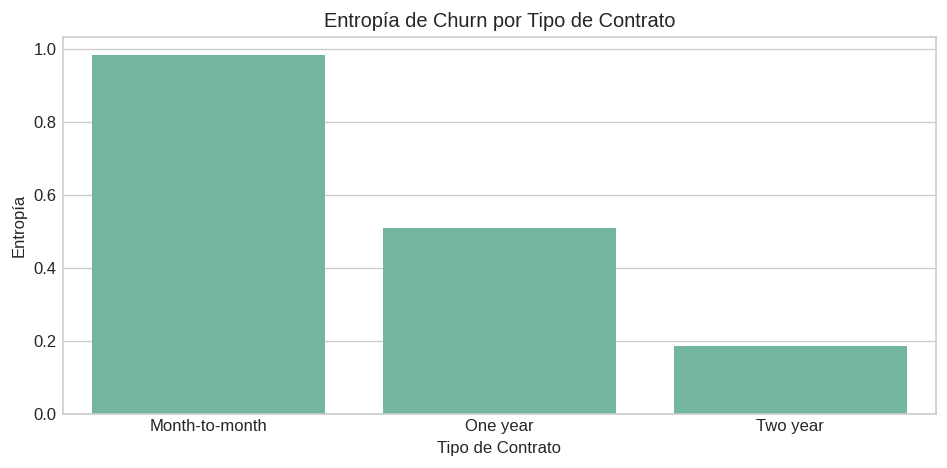

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(data=df_entropia, x="Tipo_Contrato", y="Entropia")
plt.title("Entropía de Churn por Tipo de Contrato")
plt.ylabel("Entropía")
plt.xlabel("Tipo de Contrato")
plt.tight_layout()
plt.show()

### Conclusión
Un grupo con mayor entropía presenta más mezcla entre clientes que hacen churn y los que no.  
Eso significa que es más difícil predecir el comportamiento dentro de ese segmento.

## 4. Entropía por Método de Pago

La entropía también puede analizarse por segmentos del negocio.  
En este caso evaluamos cómo cambia la incertidumbre del churn según el **método de pago del cliente**.

### Fórmula de entropía

$$
H(S) = - \sum_{i=1}^{c} p_i \log_2(p_i)
$$

Donde:

- $p_i$ es la proporción de clientes en cada clase (Churn / No Churn)

### Pregunta de negocio

¿Existen métodos de pago asociados a mayor incertidumbre o mayor riesgo de abandono?

In [ ]:
# ============================================================
# ENTROPÍA POR MÉTODO DE PAGO
# ============================================================
print("\n" + "=" * 60)
print("📊 ENTROPÍA POR MÉTODO DE PAGO")
print("=" * 60)

resultados_pago = []

for metodo in df['PaymentMethod'].unique():
    subset = df[df['PaymentMethod'] == metodo]['Churn']
    entropia = calcular_entropia(subset)
    tasa_churn = (subset == 'Yes').mean() * 100

    resultados_pago.append({
        'Metodo_Pago': metodo.replace(' (automatic)', ''),
        'N_Clientes': len(subset),
        'Tasa_Churn_%': round(tasa_churn, 2),
        'Entropia': round(entropia, 4)
    })

df_pago = pd.DataFrame(resultados_pago).sort_values('Entropia', ascending=False)
print(df_pago.to_string(index=False))


📊 ENTROPÍA POR MÉTODO DE PAGO
     Metodo_Pago  N_Clientes  Tasa_Churn_%  Entropia
Electronic check        2365         45.29    0.9936
    Mailed check        1612         19.11    0.7037
   Bank transfer        1544         16.71    0.6510
     Credit card        1522         15.24    0.6159


### Interpretación

Un método de pago con **entropía más alta** indica mayor mezcla entre clientes que abandonan y los que permanecen.

Esto implica:

- mayor incertidumbre
- mayor dificultad para clasificar el comportamiento

Un método con **entropía más baja** sugiere que los clientes tienen un comportamiento más homogéneo.

Esto puede indicar clientes más estables o patrones más claros.

---
## 5. Ganancia de Información (Information Gain)

La **ganancia de información** mide cuánto reduce la entropía una variable al dividir los datos.

### Fórmula

$$
IG(S, A) = H(S) - \sum_{v \in Valores(A)} \frac{|S_v|}{|S|} H(S_v)
$$

Donde:

- $S$ es el conjunto original
- $A$ es el atributo evaluado
- $S_v$ son los subconjuntos generados al dividir por los valores de $A$

### Interpretación
- Mayor $IG$ $\rightarrow$ mejor atributo para dividir los datos.
- Si $IG = 0$, el atributo no aporta información útil.

In [ ]:
# ============================================================
# CÁLCULO DE GANANCIA DE INFORMACIÓN
# ============================================================
def calcular_ganancia_informacion(df, atributo, objetivo='Churn'):
    """
    Calcula la Ganancia de Información de un atributo respecto al objetivo.

    Parámetros:
    -----------
    df : pd.DataFrame
        Dataset con los datos
    atributo : str
        Nombre del atributo a evaluar
    objetivo : str
        Variable objetivo (default: 'Churn')

    Retorna:
    --------
    float : Ganancia de Información
    """
    # Entropía del conjunto original
    entropia_total = calcular_entropia(df[objetivo])

    # Entropía ponderada después de la división
    entropia_ponderada = 0
    n_total = len(df)

    for valor in df[atributo].unique():
        subset = df[df[atributo] == valor]
        peso = len(subset) / n_total
        entropia_subset = calcular_entropia(subset[objetivo])
        entropia_ponderada += peso * entropia_subset

    # Ganancia de información
    ganancia = entropia_total - entropia_ponderada

    return ganancia

print("✅ Función de Ganancia de Información definida")

✅ Función de Ganancia de Información definida


In [ ]:
# ============================================================
# RANKING DE ATRIBUTOS POR GANANCIA DE INFORMACIÓN
# ============================================================
print("=" * 60)
print("📊 GANANCIA DE INFORMACIÓN POR ATRIBUTO")
print("=" * 60)

# Variables categóricas a evaluar
variables_categoricas = [
    'Contract', 'PaymentMethod', 'InternetService', 'OnlineSecurity',
    'TechSupport', 'StreamingTV', 'PaperlessBilling', 'Partner',
    'Dependents', 'SeniorCitizen', 'gender'
]

resultados_ig = []

for var in variables_categoricas:
    ig = calcular_ganancia_informacion(df, var, 'Churn')
    resultados_ig.append({
        'Atributo': var,
        'Information_Gain': round(ig, 4)
    })

df_ig = pd.DataFrame(resultados_ig).sort_values('Information_Gain', ascending=False)
print(df_ig.to_string(index=False))

print("\n💡 INTERPRETACIÓN EMPRESARIAL:")
top_atributo = df_ig.iloc[0]['Atributo']
top_ig = df_ig.iloc[0]['Information_Gain']
print(f"   - El atributo '{top_atributo}' tiene la MAYOR ganancia de información ({top_ig:.4f})")
print(f"   - Este es el mejor predictor para dividir los clientes en grupos de churn/no churn")

📊 GANANCIA DE INFORMACIÓN POR ATRIBUTO
        Atributo  Information_Gain
        Contract            0.1420
  OnlineSecurity            0.0933
     TechSupport            0.0909
 InternetService            0.0802
   PaymentMethod            0.0642
     StreamingTV            0.0460
PaperlessBilling            0.0277
      Dependents            0.0209
         Partner            0.0165
   SeniorCitizen            0.0153
          gender            0.0001

💡 INTERPRETACIÓN EMPRESARIAL:
   - El atributo 'Contract' tiene la MAYOR ganancia de información (0.1420)
   - Este es el mejor predictor para dividir los clientes en grupos de churn/no churn


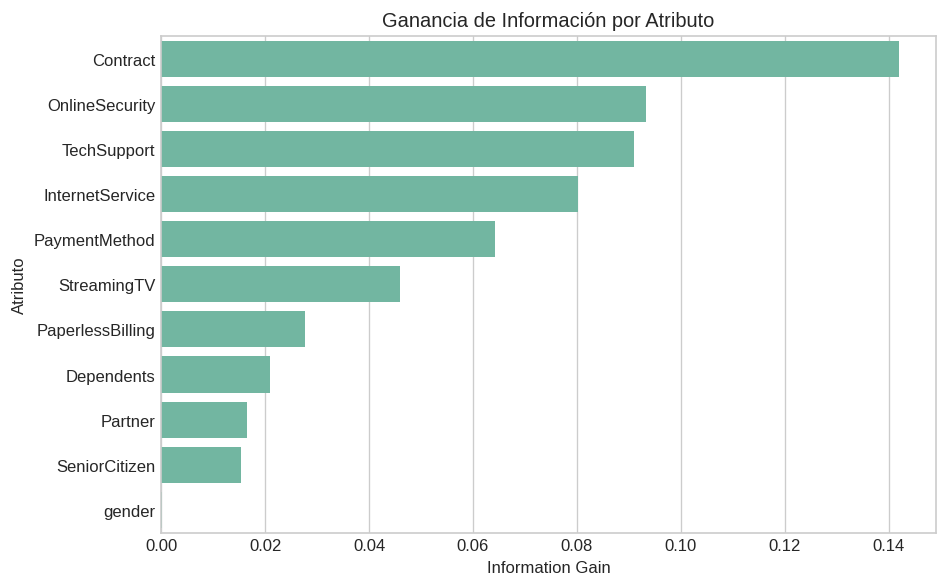

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_ig, x="Information_Gain", y="Atributo")
plt.title("Ganancia de Información por Atributo")
plt.xlabel("Information Gain")
plt.ylabel("Atributo")
plt.tight_layout()
plt.show()

### Interpretación
La variable con mayor ganancia de información es la que mejor reduce la incertidumbre del churn.

Esa variable sería una candidata natural para una primera división en un árbol de decisión.

In [ ]:
# ============================================================
# ANÁLISIS DETALLADO DEL MEJOR ATRIBUTO
# ============================================================
print("\n" + "=" * 60)
print(f"📊 ANÁLISIS DETALLADO: {top_atributo.upper()}")
print("=" * 60)

entropia_total = calcular_entropia(df['Churn'])
print(f"\nEntropía total del dataset: {entropia_total:.4f}")
print(f"\nDesglose por categoría:")

for valor in df[top_atributo].unique():
    subset = df[df[top_atributo] == valor]
    entropia_sub = calcular_entropia(subset['Churn'])
    tasa_churn = (subset['Churn'] == 'Yes').mean() * 100
    print(f"  {valor}:")
    print(f"    - Clientes: {len(subset):,}")
    print(f"    - Entropía: {entropia_sub:.4f}")
    print(f"    - Tasa Churn: {tasa_churn:.1f}%")


📊 ANÁLISIS DETALLADO: CONTRACT

Entropía total del dataset: 0.8347

Desglose por categoría:
  Month-to-month:
    - Clientes: 3,875
    - Entropía: 0.9846
    - Tasa Churn: 42.7%
  One year:
    - Clientes: 1,473
    - Entropía: 0.5080
    - Tasa Churn: 11.3%
  Two year:
    - Clientes: 1,695
    - Entropía: 0.1859
    - Tasa Churn: 2.8%


---
## 6. MÉTRICAS DE DISTANCIA


Las métricas de distancia permiten medir qué tan diferentes son dos observaciones.

### Distancia Euclidiana

$$
d(x,y) = \sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}
$$

### Distancia Manhattan

$$
d(x,y) = \sum_{i=1}^{n} |x_i-y_i|
$$

### Distancia Minkowski

$$
d(x,y) = \left( \sum_{i=1}^{n}|x_i-y_i|^p \right)^{1/p}
$$

### Interpretación
- Distancia pequeña $\rightarrow$ clientes más parecidos
- Distancia grande $\rightarrow$ clientes más diferentes

In [ ]:
# ============================================================
# PREPARACIÓN DE DATOS PARA MÉTRICAS DE DISTANCIA
# ============================================================
# Seleccionar variables numéricas relevantes
vars_numericas = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

# Crear dataset limpio para análisis de distancias
df_dist = df[vars_numericas + ['Churn']].dropna().copy()

# Normalización (escalado estándar)
scaler = StandardScaler()
df_dist_scaled = pd.DataFrame(
    scaler.fit_transform(df_dist[vars_numericas]),
    columns=vars_numericas
)
df_dist_scaled['Churn'] = df_dist['Churn'].values

print("✅ Datos normalizados para análisis de distancias")
print(f"📐 Variables utilizadas: {vars_numericas}")

✅ Datos normalizados para análisis de distancias
📐 Variables utilizadas: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']


In [ ]:
# ─────────────────────────────────────────────────────────────
# SIMULACIÓN DE DATA MARTS DEPARTAMENTALES
# ─────────────────────────────────────────────────────────────

# Data Mart 1: Departamento de SERVICIOS
dm_servicios = df[['customerID', 'PhoneService', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'TechSupport',
                    'StreamingTV', 'StreamingMovies', 'Churn']].copy()

# Data Mart 2: Departamento FINANCIERO
dm_financiero = df[['customerID', 'Contract', 'PaperlessBilling',
                     'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
                     'tenure', 'Churn']].copy()

# Data Mart 3: Departamento DEMOGRAFICO
dm_demografico = df[['customerID', 'gender', 'SeniorCitizen',
                      'Partner', 'Dependents', 'Churn']].copy()

print("=== ARQUITECTURA DE DATA MARTS — TelcoPerú ===")
print(f"  DW Central (dataset completo):    {df.shape[0]:>5} filas x {df.shape[1]:>2} columnas")
print(f"  Data Mart Servicios:              {dm_servicios.shape[0]:>5} filas x {dm_servicios.shape[1]:>2} columnas")
print(f"  Data Mart Financiero:             {dm_financiero.shape[0]:>5} filas x {dm_financiero.shape[1]:>2} columnas")
print(f"  Data Mart Demografico:            {dm_demografico.shape[0]:>5} filas x {dm_demografico.shape[1]:>2} columnas")

# Análisis de churn por Data Mart (perspectiva OLAP: Slice)
print("\n=== ANÁLISIS OLAP — Slice por tipo de contrato (DM Financiero) ===")
for contrato in dm_financiero['Contract'].unique():
    subset = dm_financiero[dm_financiero['Contract'] == contrato]
    churn_pct = subset['Churn'].map({'Yes':1,'No':0}).mean() * 100



=== ARQUITECTURA DE DATA MARTS — TelcoPerú ===
  DW Central (dataset completo):     7043 filas x 22 columnas
  Data Mart Servicios:               7043 filas x  9 columnas
  Data Mart Financiero:              7043 filas x  8 columnas
  Data Mart Demografico:             7043 filas x  6 columnas

=== ANÁLISIS OLAP — Slice por tipo de contrato (DM Financiero) ===


=== DRILL-DOWN: Clientes mes-a-mes por método de pago ===
PaymentMethod              Churn
Bank transfer (automatic)  No       65.9
                           Yes      34.1
Credit card (automatic)    No       67.2
                           Yes      32.8
Electronic check           Yes      53.7
                           No       46.3
Mailed check               No       68.4
                           Yes      31.6


/tmp/ipykernel_4146/406117661.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tabla_olap = dm_mensual.groupby('PaymentMethod').apply(


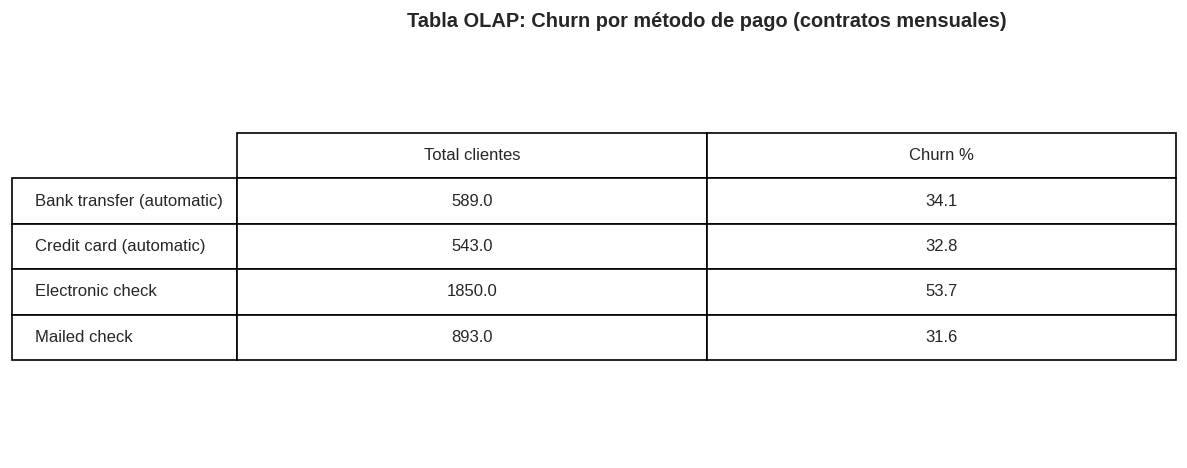

In [ ]:
# ─────────────────────────────────────────────────────────────
# OPERACIÓN OLAP: DRILL-DOWN en el Data Mart Financiero
# De tipo de contrato → desglose por método de pago
# ─────────────────────────────────────────────────────────────
print("=== DRILL-DOWN: Clientes mes-a-mes por método de pago ===")
dm_mensual = dm_financiero[dm_financiero['Contract'] == 'Month-to-month']
pivot = dm_mensual.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).mul(100).round(1)
print(pivot.to_string())

# Visualización tipo tabla OLAP
fig, ax = plt.subplots(figsize=(10, 4))
tabla_olap = dm_mensual.groupby('PaymentMethod').apply(
    lambda x: pd.Series({
        'Total clientes': len(x),
        'Churn %': x['Churn'].map({'Yes':1,'No':0}).mean()*100
    })
).round(1)
ax.axis('off')
t = ax.table(cellText=tabla_olap.values,
             colLabels=tabla_olap.columns,
             rowLabels=tabla_olap.index,
             cellLoc='center', loc='center')
t.auto_set_font_size(False)
t.set_fontsize(10)
t.scale(1, 2)
plt.title('Tabla OLAP: Churn por método de pago (contratos mensuales)', fontweight='bold')
plt.tight_layout()
plt.savefig('tabla_olap.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────
# PASO 1: Seleccionar variables numéricas y preparar datos
# ─────────────────────────────────────────────────────────────
vars_num = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Mostrar los primeros 5 perfiles
print("Primeros 5 perfiles de clientes (variables numéricas):")
print(df[vars_num].head().to_string())
print()

# ─────────────────────────────────────────────────────────────
# PASO 2: Calcular distancias SIN normalizar (2 clientes)
# ─────────────────────────────────────────────────────────────
clienteA = df[vars_num].iloc[0].values
clienteB = df[vars_num].iloc[1].values
clienteC = df[vars_num].iloc[100].values  # Cliente distante

print(f"Cliente A: tenure={clienteA[0]}, MonthlyCharges={clienteA[1]:.1f}, TotalCharges={clienteA[2]:.1f}")
print(f"Cliente B: tenure={clienteB[0]}, MonthlyCharges={clienteB[1]:.1f}, TotalCharges={clienteB[2]:.1f}")
print(f"Cliente C: tenure={clienteC[0]}, MonthlyCharges={clienteC[1]:.1f}, TotalCharges={clienteC[2]:.1f}")

print("\n=== DISTANCIAS SIN NORMALIZAR ===")
print(f"Euclidiana A-B: {euclidean(clienteA, clienteB):.2f}")
print(f"Manhattan  A-B: {cityblock(clienteA, clienteB):.2f}")
print(f"Euclidiana A-C: {euclidean(clienteA, clienteC):.2f}")
print(f"Manhattan  A-C: {cityblock(clienteA, clienteC):.2f}")


Primeros 5 perfiles de clientes (variables numéricas):
   tenure  MonthlyCharges  TotalCharges
0       1           29.85         29.85
1      34           56.95       1889.50
2       2           53.85        108.15
3      45           42.30       1840.75
4       2           70.70        151.65

Cliente A: tenure=1.0, MonthlyCharges=29.9, TotalCharges=29.9
Cliente B: tenure=34.0, MonthlyCharges=57.0, TotalCharges=1889.5
Cliente C: tenure=1.0, MonthlyCharges=20.2, TotalCharges=20.2

=== DISTANCIAS SIN NORMALIZAR ===
Euclidiana A-B: 1860.14
Manhattan  A-B: 1919.75
Euclidiana A-C: 13.65
Manhattan  A-C: 19.30


---
## 7. Métricas de Similitud

Mientras la distancia mide diferencia, la similitud mide qué tan parecidos son dos elementos.

### Similitud del Coseno

$$
\cos(\theta)=\frac{A \cdot B}{\|A\|\|B\|}
$$

### Índice de Jaccard

$$
J(A,B)=\frac{|A \cap B|}{|A \cup B|}
$$

### Correlación de Pearson

$$
r = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \sum(y_i-\bar{y})^2}}
$$

=== DISTANCIAS CON NORMALIZACIÓN MinMax [0,1] ===
Euclidiana A-B: 0.5734
Manhattan  A-B: 0.9426
Euclidiana A-C: 0.0960
Manhattan  A-C: 0.0971


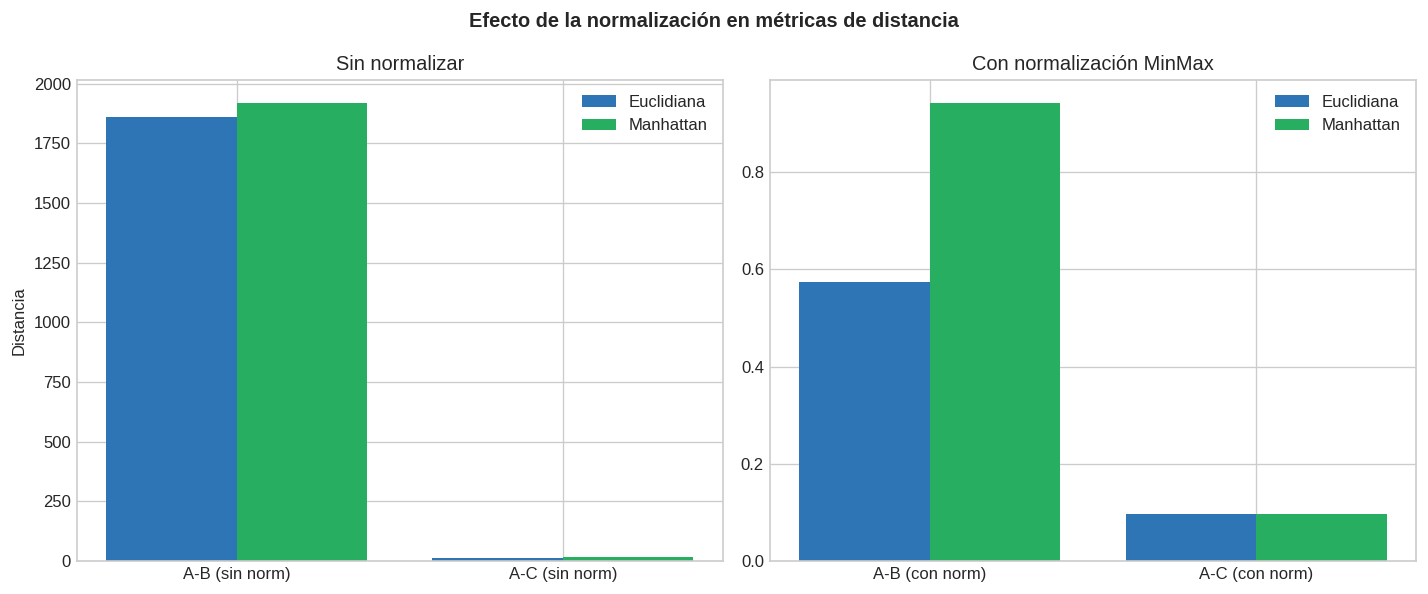

In [ ]:

# ─────────────────────────────────────────────────────────────
# PASO 3: Normalizar y recalcular — ver el efecto
# ─────────────────────────────────────────────────────────────
scaler = MinMaxScaler()
df_norm = pd.DataFrame(
    scaler.fit_transform(df[vars_num]),
    columns=vars_num
)

A_norm = df_norm.iloc[0].values
B_norm = df_norm.iloc[1].values
C_norm = df_norm.iloc[100].values

print("=== DISTANCIAS CON NORMALIZACIÓN MinMax [0,1] ===")
print(f"Euclidiana A-B: {euclidean(A_norm, B_norm):.4f}")
print(f"Manhattan  A-B: {cityblock(A_norm, B_norm):.4f}")
print(f"Euclidiana A-C: {euclidean(A_norm, C_norm):.4f}")
print(f"Manhattan  A-C: {cityblock(A_norm, C_norm):.4f}")

# ─────────────────────────────────────────────────────────────
# PASO 4: Comparar visualmente el efecto de la normalización
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['A-B (sin norm)', 'A-C (sin norm)']
eucl_sin = [euclidean(clienteA, clienteB), euclidean(clienteA, clienteC)]
manh_sin = [cityblock(clienteA, clienteB), cityblock(clienteA, clienteC)]

labels_n = ['A-B (con norm)', 'A-C (con norm)']
eucl_con = [euclidean(A_norm, B_norm), euclidean(A_norm, C_norm)]
manh_con = [cityblock(A_norm, B_norm), cityblock(A_norm, C_norm)]

x = range(2)
axes[0].bar([i-0.2 for i in x], eucl_sin, 0.4, label='Euclidiana', color='#2E75B6')
axes[0].bar([i+0.2 for i in x], manh_sin, 0.4, label='Manhattan', color='#27AE60')
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(labels)
axes[0].set_title('Sin normalizar'); axes[0].legend(); axes[0].set_ylabel('Distancia')

axes[1].bar([i-0.2 for i in x], eucl_con, 0.4, label='Euclidiana', color='#2E75B6')
axes[1].bar([i+0.2 for i in x], manh_con, 0.4, label='Manhattan', color='#27AE60')
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(labels_n)
axes[1].set_title('Con normalización MinMax'); axes[1].legend()

plt.suptitle('Efecto de la normalización en métricas de distancia', fontweight='bold')
plt.tight_layout()
plt.savefig('distancias_comparacion.png', dpi=120)
plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────
# SIMILITUD DEL COSENO entre perfiles de clientes
# ─────────────────────────────────────────────────────────────
sim_coseno_AB = 1 - cosine(A_norm, B_norm)
sim_coseno_AC = 1 - cosine(A_norm, C_norm)

print("=== SIMILITUD DEL COSENO (variables numéricas normalizadas) ===")
print(f"Similitud Coseno A-B: {sim_coseno_AB:.4f}")
print(f"Similitud Coseno A-C: {sim_coseno_AC:.4f}")
print()

# ─────────────────────────────────────────────────────────────
# ÍNDICE DE JACCARD — servicios contratados (variables binarias)
# ─────────────────────────────────────────────────────────────
# Convertir servicios a binario
servicios_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                  'TechSupport', 'StreamingTV', 'StreamingMovies']

def binarizar_servicios(df, cols):
    df_bin = df[cols].copy()
    for col in cols:
        df_bin[col] = df_bin[col].apply(lambda x: 1 if x == 'Yes' else 0)
    return df_bin

df_servicios_bin = binarizar_servicios(df, servicios_cols)

def jaccard(v1, v2):
    interseccion = sum(a & b for a, b in zip(v1, v2))
    union = sum(1 for a, b in zip(v1, v2) if a | b)
    return interseccion / union if union > 0 else 0

sA = df_servicios_bin.iloc[0].values
sB = df_servicios_bin.iloc[1].values
sC = df_servicios_bin.iloc[100].values

print("=== ÍNDICE DE JACCARD (servicios contratados) ===")
print(f"  Cliente A: {dict(zip(servicios_cols, sA))}")
print(f"  Cliente B: {dict(zip(servicios_cols, sB))}")
print(f"  Cliente C: {dict(zip(servicios_cols, sC))}")
print()
print(f"Jaccard A-B: {jaccard(sA, sB):.4f}")
print(f"Jaccard A-C: {jaccard(sA, sC):.4f}")


=== SIMILITUD DEL COSENO (variables numéricas normalizadas) ===
Similitud Coseno A-B: 0.6823
Similitud Coseno A-C: 0.8769

=== ÍNDICE DE JACCARD (servicios contratados) ===
  Cliente A: {'PhoneService': np.int64(0), 'OnlineSecurity': np.int64(0), 'OnlineBackup': np.int64(1), 'TechSupport': np.int64(0), 'StreamingTV': np.int64(0), 'StreamingMovies': np.int64(0)}
  Cliente B: {'PhoneService': np.int64(1), 'OnlineSecurity': np.int64(1), 'OnlineBackup': np.int64(0), 'TechSupport': np.int64(0), 'StreamingTV': np.int64(0), 'StreamingMovies': np.int64(0)}
  Cliente C: {'PhoneService': np.int64(1), 'OnlineSecurity': np.int64(0), 'OnlineBackup': np.int64(0), 'TechSupport': np.int64(0), 'StreamingTV': np.int64(0), 'StreamingMovies': np.int64(0)}

Jaccard A-B: 0.0000
Jaccard A-C: 0.0000


In [ ]:
# ─────────────────────────────────────────────────────────────
# FUNCIÓN DE ENTROPÍA — implementación manual
# ─────────────────────────────────────────────────────────────
def calcular_entropia(serie):
    """Calcula la entropía de Shannon de una serie categórica."""
    conteo = Counter(serie)
    total = len(serie)
    entropia = 0
    for clase, freq in conteo.items():
        p = freq / total
        if p > 0:
            entropia -= p * np.log2(p)
    return entropia

# ─────────────────────────────────────────────────────────────
# VERIFICACIÓN CON CASOS CONOCIDOS
# ─────────────────────────────────────────────────────────────
caso_puro      = ['Churn'] * 10                             # 100% churn
caso_mitad     = ['Churn'] * 5 + ['No Churn'] * 5          # 50/50
caso_real      = ['Churn'] * 2 + ['No Churn'] * 8          # 20/80
caso_desbalance = ['Churn'] * 1 + ['No Churn'] * 9         # 10/90

print("=== VERIFICACIÓN DEL CONCEPTO DE ENTROPÍA ===")
print(f"  Conjunto puro (100% Churn):     H = {calcular_entropia(caso_puro):.4f}  ← Esperado: 0.0")
print(f"  Conjunto 50/50:                 H = {calcular_entropia(caso_mitad):.4f}  ← Esperado: 1.0")
print(f"  Conjunto 20% Churn / 80% No:    H = {calcular_entropia(caso_real):.4f}  ← Esperado ~0.72")
print(f"  Conjunto 10% Churn / 90% No:    H = {calcular_entropia(caso_desbalance):.4f}  ← Esperado ~0.47")


=== VERIFICACIÓN DEL CONCEPTO DE ENTROPÍA ===
  Conjunto puro (100% Churn):     H = 0.0000  ← Esperado: 0.0
  Conjunto 50/50:                 H = 1.0000  ← Esperado: 1.0
  Conjunto 20% Churn / 80% No:    H = 0.7219  ← Esperado ~0.72
  Conjunto 10% Churn / 90% No:    H = 0.4690  ← Esperado ~0.47


In [ ]:
# ─────────────────────────────────────────────────────────────
# ENTROPÍA GLOBAL — ¿qué tan incierta es la variable Churn?
# ─────────────────────────────────────────────────────────────
entropia_global = calcular_entropia(df['Churn'])
dist_churn = Counter(df['Churn'])
total = len(df)

print("=== ENTROPÍA GLOBAL DE CHURN EN EL DATASET TELCO ===")
print(f"  Distribución: {dict(dist_churn)}")
print(f"  No Churn: {dist_churn['No']/total*100:.1f}%  |  Churn: {dist_churn['Yes']/total*100:.1f}%")
print(f"  Entropía global: H = {entropia_global:.4f}")
print()
print("  Interpretación:")
print(f"  → Un árbol sin NINGÚN atributo predice siempre 'No Churn'")
print(f"    con error del {dist_churn['Yes']/total*100:.1f}%. La entropía de {entropia_global:.4f}")
print(f"    nos dice cuánta incertidumbre debemos reducir con nuestras variables.")


=== ENTROPÍA GLOBAL DE CHURN EN EL DATASET TELCO ===
  Distribución: {'No': 5174, 'Yes': 1869}
  No Churn: 73.5%  |  Churn: 26.5%
  Entropía global: H = 0.8347

  Interpretación:
  → Un árbol sin NINGÚN atributo predice siempre 'No Churn'
    con error del 26.5%. La entropía de 0.8347
    nos dice cuánta incertidumbre debemos reducir con nuestras variables.


Entropía global del dataset: H = 0.8347

=== Contract ===
  Month-to-month                 n=3875  H=0.9846  Churn=42.7%
  One year                       n=1473  H=0.5080  Churn=11.3%
  Two year                       n=1695  H=0.1859  Churn=2.8%

=== InternetService ===
  DSL                            n=2421  H=0.7006  Churn=19.0%
  Fiber optic                    n=3096  H=0.9810  Churn=41.9%
  No                             n=1526  H=0.3809  Churn=7.4%

=== PaymentMethod ===
  Bank transfer (automatic)      n=1544  H=0.6510  Churn=16.7%
  Credit card (automatic)        n=1522  H=0.6159  Churn=15.2%
  Electronic check               n=2365  H=0.9936  Churn=45.3%
  Mailed check                   n=1612  H=0.7037  Churn=19.1%

=== PaperlessBilling ===
  No                             n=2872  H=0.6421  Churn=16.3%
  Yes                            n=4171  H=0.9206  Churn=33.6%

=== SeniorCitizen ===
  0                              n=5901  H=0.7884  Churn=23.6%
  1                         

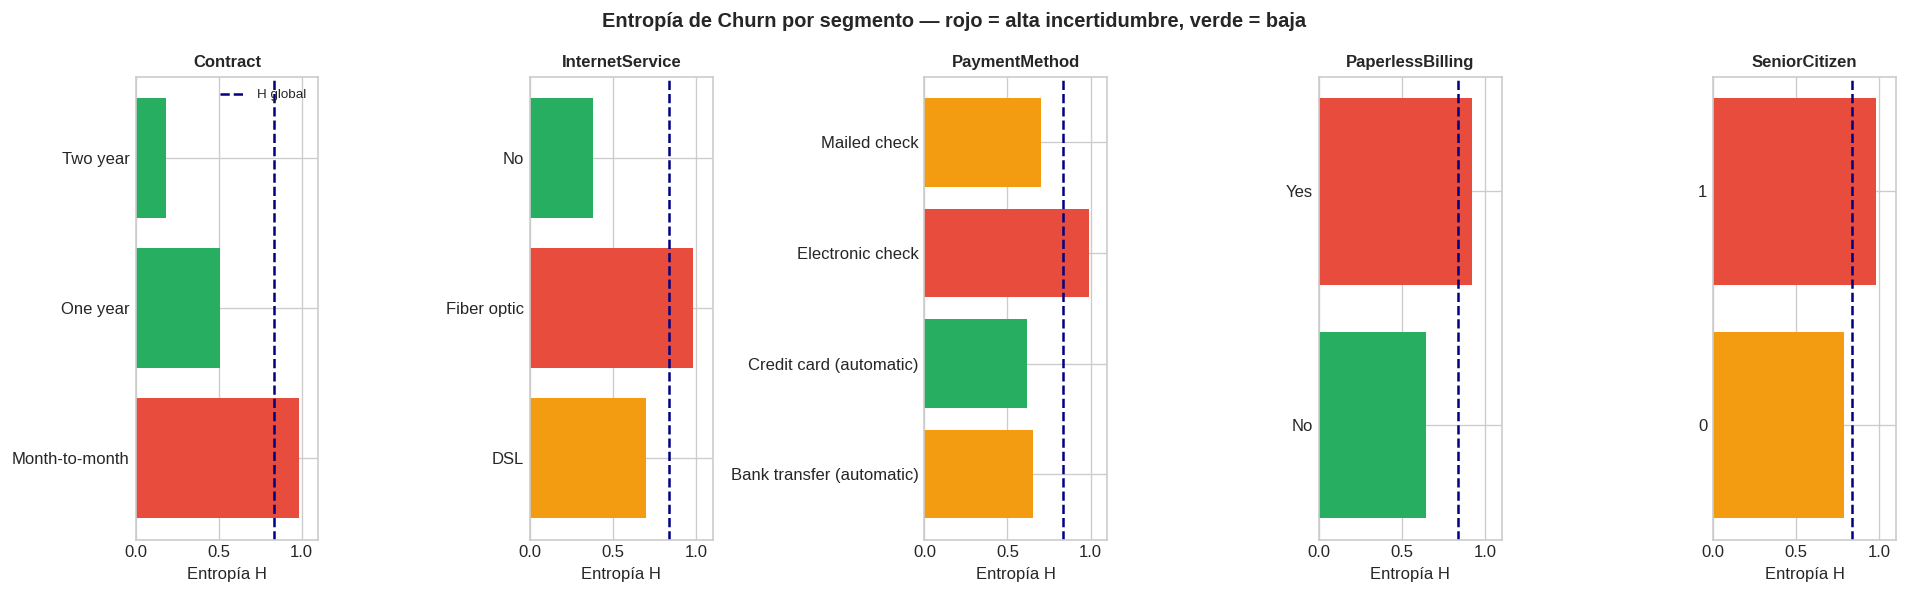

In [ ]:
# ────────────────────────────────────────────────────────────
# ENTROPÍA SEGMENTADA — análisis de pureza por variable
#────────────────────────────────────────────────────────────
variables_cat = ['Contract', 'InternetService', 'PaymentMethod',
                 'PaperlessBilling', 'SeniorCitizen']

print(f"Entropía global del dataset: H = {entropia_global:.4f}\n")

resultados_entropia = []
for var in variables_cat:
    print(f"=== {var} ===")
    entropias_segmento = []
    for valor in sorted(df[var].astype(str).unique()):
        subset = df[df[var].astype(str) == valor]['Churn']
        ent = calcular_entropia(subset)
        dist = dict(Counter(subset))
        n = len(subset)
        churn_pct = dist.get('Yes', 0) / n * 100
        print(f"  {valor:<30} n={n:>4}  H={ent:.4f}  Churn={churn_pct:.1f}%")
        entropias_segmento.append((valor, ent, n))
    print()
    resultados_entropia.append((var, entropias_segmento))
# ─────────────────────────────────────────────────────────────
# VISUALIZACIÓN: Heatmap de entropía por segmento
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(variables_cat), figsize=(16, 5))

for i, (var, segmentos) in enumerate(resultados_entropia):
    valores = [s[0] for s in segmentos]
    entropias = [s[1] for s in segmentos]
    colores = ['#E74C3C' if e > 0.85 else '#F39C12' if e > 0.65 else '#27AE60' for e in entropias]

    axes[i].barh(valores, entropias, color=colores)
    axes[i].axvline(x=entropia_global, color='navy', linestyle='--', linewidth=1.5, label='H global')
    axes[i].set_xlim(0, 1.1)
    axes[i].set_title(var, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Entropía H')
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Entropía de Churn por segmento — rojo = alta incertidumbre, verde = baja',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('entropia_segmentos.png', dpi=120, bbox_inches='tight')
plt.show()


Entropía global: H = 0.8347

=== RANKING DE VARIABLES POR GANANCIA DE INFORMACIÓN ===
Variable                         IG   Reducción %  Utilidad
----------------------------------------------------------------------
  Contract                   0.1420        17.0%  ALTA
  OnlineSecurity             0.0933        11.2%  ALTA
  TechSupport                0.0909        10.9%  ALTA
  InternetService            0.0802         9.6%  ALTA
  OnlineBackup               0.0675         8.1%  ALTA
  PaymentMethod              0.0642         7.7%  ALTA
  StreamingMovies            0.0462         5.5%  MEDIA
  StreamingTV                0.0460         5.5%  MEDIA
  PaperlessBilling           0.0277         3.3%  MEDIA
  Dependents                 0.0209         2.5%  MEDIA
  Partner                    0.0165         2.0%  MEDIA
  SeniorCitizen              0.0153         1.8%  MEDIA
  MultipleLines              0.0012         0.1%  BAJA
  PhoneService               0.0001         0.0%  BAJA
  gende

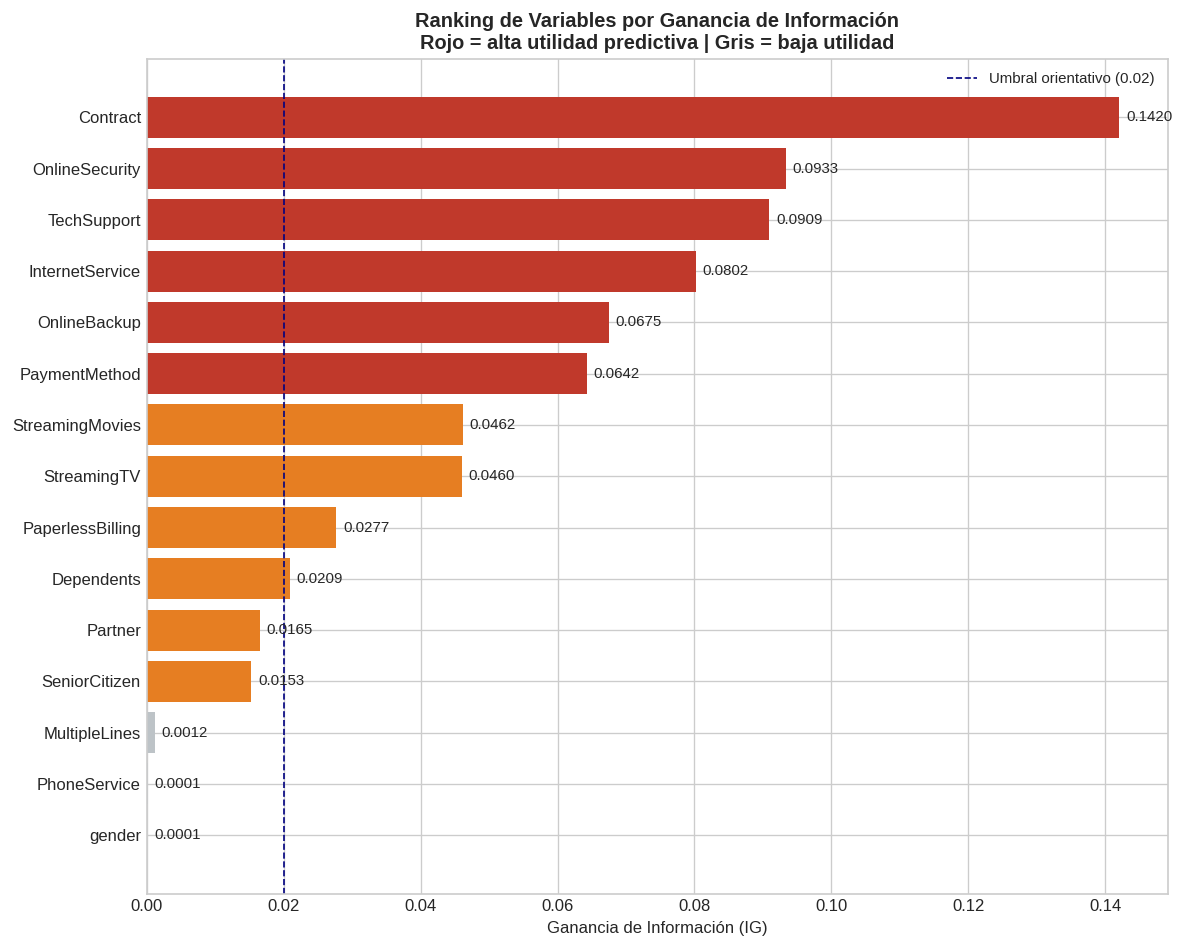


=== VERIFICACIÓN CRUZADA CON EL LAB 2 ===
Variable con MAYOR IG: Contract (IG = 0.1420)
Variable con MENOR IG: gender (IG = 0.0001)

Si en el Lab 2 la variable raíz del árbol fue similar a la de mayor IG,


In [ ]:
# ─────────────────────────────────────────────────────────────
# FUNCIÓN DE GANANCIA DE INFORMACIÓN
# ─────────────────────────────────────────────────────────────
def ganancia_informacion(df, atributo, target='Churn'):
    """Calcula la Ganancia de Información de un atributo categórico."""
    entropia_total = calcular_entropia(df[target])
    valores = df[atributo].astype(str).unique()
    entropia_ponderada = 0
    for valor in valores:
        subset = df[df[atributo].astype(str) == valor][target]
        peso = len(subset) / len(df)
        entropia_ponderada += peso * calcular_entropia(subset)
    return entropia_total - entropia_ponderada

# ─────────────────────────────────────────────────────────────
# CALCULAR IG PARA TODAS LAS VARIABLES CATEGÓRICAS
# ─────────────────────────────────────────────────────────────
variables_todas = ['Contract', 'InternetService', 'PaymentMethod',
                   'PaperlessBilling', 'SeniorCitizen', 'Partner',
                   'Dependents', 'PhoneService', 'OnlineSecurity',
                   'OnlineBackup', 'TechSupport', 'StreamingTV',
                   'StreamingMovies', 'MultipleLines', 'gender']

resultados_ig = {}
for var in variables_todas:
    ig = ganancia_informacion(df, var)
    resultados_ig[var] = ig

# Ordenar por IG descendente
ig_ordenado = sorted(resultados_ig.items(), key=lambda x: x[1], reverse=True)

print(f"Entropía global: H = {entropia_global:.4f}")
print()
print("=== RANKING DE VARIABLES POR GANANCIA DE INFORMACIÓN ===")
print(f"{'Variable':<25}  {'IG':>8}  {'Reducción %':>12}  {'Utilidad'}")
print("-" * 70)
for var, ig in ig_ordenado:
    reduccion = (ig / entropia_global) * 100
    utilidad = "ALTA" if ig > 0.05 else "MEDIA" if ig > 0.01 else "BAJA"
    print(f"  {var:<23}  {ig:>8.4f}  {reduccion:>10.1f}%  {utilidad}")
# ─────────────────────────────────────────────────────────────
# VISUALIZACIÓN: Ranking de IG — gráfico de barras
# ─────────────────────────────────────────────────────────────
variables_ig = [v[0] for v in ig_ordenado]
valores_ig   = [v[1] for v in ig_ordenado]
colores_ig   = ['#C0392B' if ig > 0.05 else '#E67E22' if ig > 0.01 else '#BDC3C7'
                for ig in valores_ig]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(len(variables_ig)), valores_ig[::-1], color=colores_ig[::-1])
ax.set_yticks(range(len(variables_ig)))
ax.set_yticklabels(variables_ig[::-1], fontsize=10)
ax.set_xlabel('Ganancia de Información (IG)')
ax.set_title('Ranking de Variables por Ganancia de Información\n'
             'Rojo = alta utilidad predictiva | Gris = baja utilidad',
             fontweight='bold')

# Etiquetas de valor
for i, (bar, val) in enumerate(zip(bars, valores_ig[::-1])):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

# Línea de referencia
ax.axvline(x=0.02, color='navy', linestyle='--', linewidth=1, label='Umbral orientativo (0.02)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('ganancia_informacion.png', dpi=120, bbox_inches='tight')
plt.show()

# Verificación cruzada con el árbol del Lab 2
print("\n=== VERIFICACIÓN CRUZADA CON EL LAB 2 ===")
print(f"Variable con MAYOR IG: {ig_ordenado[0][0]} (IG = {ig_ordenado[0][1]:.4f})")
print(f"Variable con MENOR IG: {ig_ordenado[-1][0]} (IG = {ig_ordenado[-1][1]:.4f})")
print()
print("Si en el Lab 2 la variable raíz del árbol fue similar a la de mayor IG,")


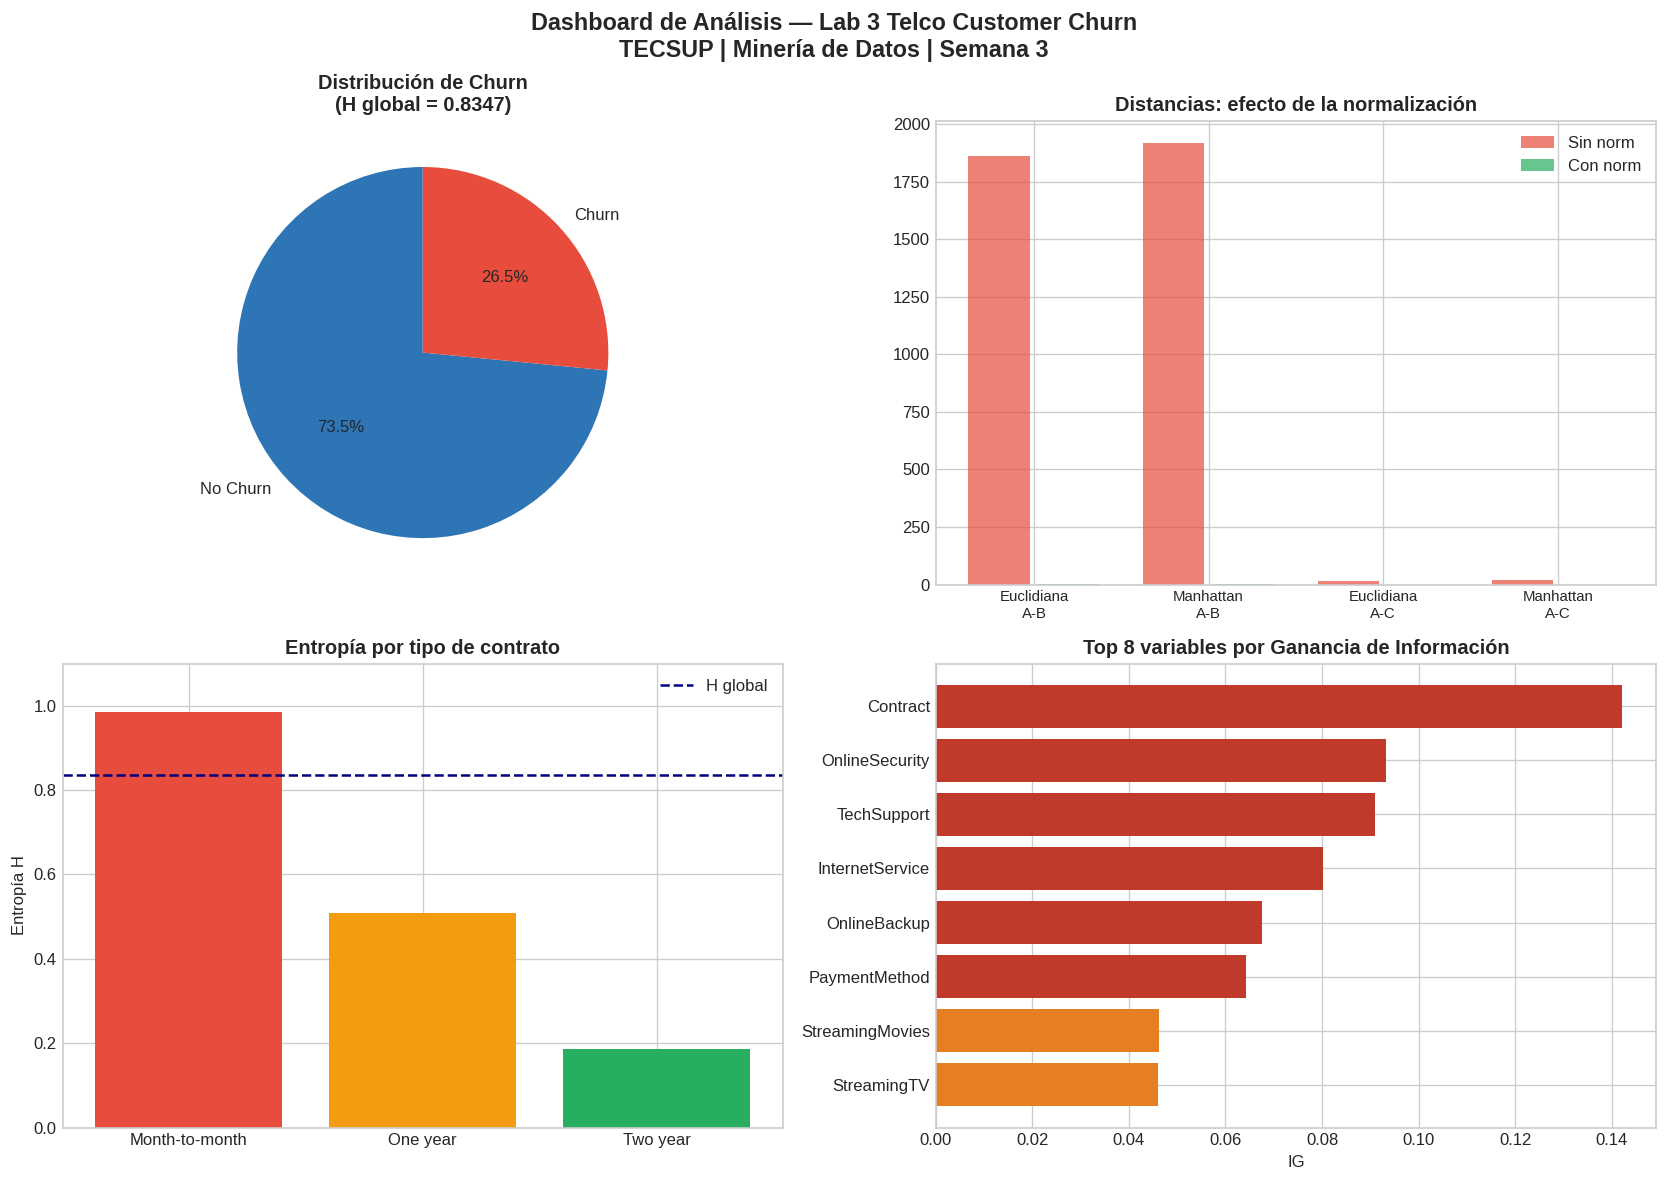

Dashboard guardado como dashboard_lab3.png


In [ ]:
# ─────────────────────────────────────────────────────────────
# PANEL RESUMEN: DW + Distancias + Entropía + IG integrados
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Distribución de churn (contexto del dataset)
axes[0,0].pie([dist_churn['No'], dist_churn['Yes']],
              labels=['No Churn', 'Churn'],
              colors=['#2E75B6', '#E74C3C'],
              autopct='%1.1f%%', startangle=90)
axes[0,0].set_title(f'Distribución de Churn\n(H global = {entropia_global:.4f})',
                     fontweight='bold')

# Panel 2: Comparación de distancias (con y sin normalización)
metricas = ['Euclidiana\nA-B', 'Manhattan\nA-B', 'Euclidiana\nA-C', 'Manhattan\nA-C']
sin_norm = [euclidean(clienteA,clienteB), cityblock(clienteA,clienteB),
            euclidean(clienteA,clienteC), cityblock(clienteA,clienteC)]
con_norm = [euclidean(A_norm,B_norm), cityblock(A_norm,B_norm),
            euclidean(A_norm,C_norm), cityblock(A_norm,C_norm)]
x2 = range(4)
axes[0,1].bar([i-0.2 for i in x2], sin_norm, 0.35, label='Sin norm', color='#E74C3C', alpha=0.7)
axes[0,1].bar([i+0.2 for i in x2], con_norm, 0.35, label='Con norm', color='#27AE60', alpha=0.7)
axes[0,1].set_xticks(list(x2)); axes[0,1].set_xticklabels(metricas, fontsize=9)
axes[0,1].set_title('Distancias: efecto de la normalización', fontweight='bold')
axes[0,1].legend()

# Panel 3: Entropía por tipo de contrato
contratos = ['Month-to-month', 'One year', 'Two year']
ent_contratos = [calcular_entropia(df[df['Contract']==c]['Churn']) for c in contratos]
colors_c = ['#E74C3C' if e > 0.8 else '#F39C12' if e > 0.5 else '#27AE60' for e in ent_contratos]
axes[1,0].bar(contratos, ent_contratos, color=colors_c)
axes[1,0].axhline(y=entropia_global, color='navy', linestyle='--', label='H global')
axes[1,0].set_title('Entropía por tipo de contrato', fontweight='bold')
axes[1,0].set_ylim(0, 1.1); axes[1,0].legend()
axes[1,0].set_ylabel('Entropía H')

# Panel 4: Top 8 variables por IG
top8 = ig_ordenado[:8]
vars_top = [v[0] for v in top8]
ig_top   = [v[1] for v in top8]
colores_top = ['#C0392B' if ig > 0.05 else '#E67E22' for ig in ig_top]
axes[1,1].barh(vars_top[::-1], ig_top[::-1], color=colores_top[::-1])
axes[1,1].set_title('Top 8 variables por Ganancia de Información', fontweight='bold')
axes[1,1].set_xlabel('IG')

plt.suptitle('Dashboard de Análisis — Lab 3 Telco Customer Churn\nTECSUP | Minería de Datos | Semana 3',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard_lab3.png', dpi=120, bbox_inches='tight')
plt.show()
print("Dashboard guardado como dashboard_lab3.png")


## 7. Resumen Ejecutivo

En este notebook se aplicaron conceptos fundamentales de minería de datos al problema de churn en telecomunicaciones.

### Hallazgos principales
- La **entropía** permitió medir la incertidumbre del churn.
- La **ganancia de información** identificó variables más útiles para separar clientes.
- Las **métricas de distancia** compararon perfiles de clientes.
- Las **métricas de similitud** midieron qué tan parecidos son sus comportamientos.

### Conclusión
Estos conceptos son la base matemática de muchos algoritmos posteriores de minería de datos, como árboles de decisión, clustering y métodos basados en vecinos.

## 8. Preguntas de Reflexión

1. ¿Qué significa que la entropía del churn sea relativamente alta?
Significa que hay incertidumbre en los datos. No es obvio a simple vista quién se va y quién se queda. Los datos están "mezclados" (ni todos se van, ni todos se quedan), lo que hace necesario usar un modelo inteligente para encontrar patrones ocultos. Si la entropía fuera baja, sería fácil adivinar (ej. "todos se van"), pero como es alta, el problema es complejo.

2. ¿Por qué una variable con mayor ganancia de información es importante?
Porque es la mejor pista para predecir. Una variable con alta ganancia de información (como la "Edad" o el "Saldo") ayuda a "limpiar" la incertidumbre. Te dice: "Si miras esta variable, puedes separar a los clientes que se van de los que se quedan mucho mejor que con las otras". Es el filtro más eficaz.

3. ¿Cuándo conviene usar distancia y cuándo similitud?
Distancia: Se usa para agrupar o detectar anomalías. Responde a "¿Qué tan diferente es este cliente de los demás?". (Ej. Detectar clientes con comportamiento muy raro).
Similitud: Se usa para recomendar o encontrar patrones. Responde a "¿A quién se parece este cliente?". (Ej. Este cliente se parece a este otro que ya se fue, así que quizás se vaya también).

4. ¿Qué relación observas entre estos conceptos y el problema de churn?
Principalmente 3
La Entropía nos dice qué tan difícil es el rompecabezas.
La Ganancia de Información nos dice qué piezas (variables) son claves para armarlo.
La Distancia/Similitud nos permiten encontrar grupos de clientes con comportamientos similares para tratarlos en conjunto.

5. ¿Qué concepto te pareció más útil para entender el comportamiento de los clientes?

Es la más útil para el negocio porque es interpretable. No te dice solo un número matemático, te traduce el problema a una acción: "La variable 'Productos' es clave, si tienen 3 productos se van". Eso permite al banco tomar decisiones reales (mejorar esos productos).


##🎯 Introducción — Extensión de Modelado

En esta sección se presenta una extensión del laboratorio orientada al modelado predictivo. Luego de haber realizado el análisis exploratorio, el cálculo de entropía y la ganancia de información, se procede a construir modelos de clasificación que permitan predecir el churn de los clientes.

SMOTE se aplicó únicamente al conjunto de entrenamiento para evitar data leakage, en concordancia con las buenas prácticas del pipeline de preparación de datos. Eso conversa muy bien con la advertencia de tu PPT sobre no filtrar información del test al train.

El objetivo de esta extensión es comparar distintos enfoques de modelado y determinar cuál resulta más adecuado desde el punto de vista del negocio, priorizando la correcta identificación de los clientes que se retiran. Para ello, se analizan métricas como el recall y el F1-score, que permiten evaluar el desempeño del modelo en la detección del churn.

A continuación, se presentan los códigos correspondientes al entrenamiento, evaluación y comparación de los modelos.

Vamos a trabajar lo siguiente:
3 modelos:

🔴 Sin balanceo + todas las variables

🟢 Con SMOTE + todas las variables

🔵 Con SMOTE + variables importantes

Luego de ello comparamos

In [ ]:
# ============================================================
# EXTENSIÓN FINAL DEL LABORATORIO:
# COMPARACIÓN DE MODELOS DE CLASIFICACIÓN
# 1) Sin balanceo + todas las variables
# 2) Con SMOTE + todas las variables
# 3) Con SMOTE + variables importantes (según IG)
# ============================================================


# FIX: Downgrade numpy for compatibility with imbalanced-learn
!pip install imbalanced-learn
!pip install imbalanced-learn -q


In [ ]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from imblearn.over_sampling import SMOTE
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 120


In [ ]:
# ============================================================
# 2. CARGA Y LIMPIEZA DEL DATASET
# ============================================================
URL = ('https://raw.githubusercontent.com/IBM/telco-customer-churn'
       '-on-icp4d/master/data/Telco-Customer-Churn.csv')

df = pd.read_csv(URL)

# Corrección de TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Variable objetivo binaria
df['Churn_num'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Dimensiones del dataset:", df.shape)
print("\nDistribución de la variable objetivo:")
print(df['Churn_num'].value_counts())
print("\nPorcentaje de churn:")
print((df['Churn_num'].value_counts(normalize=True) * 100).round(2))

Dimensiones del dataset: (7043, 22)

Distribución de la variable objetivo:
Churn_num
0    5174
1    1869
Name: count, dtype: int64

Porcentaje de churn:
Churn_num
0    73.46
1    26.54
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# 3. VARIABLES IMPORTANTES SEGÚN TU ANÁLISIS DE IG
# ============================================================
variables_importantes = [
    'Contract',
    'OnlineSecurity',
    'TechSupport',
    'InternetService',
    'OnlineBackup',
    'PaymentMethod',
    'StreamingMovies',
    'StreamingTV'
]


In [ ]:
# ============================================================
# 4. PREPARACIÓN DE DATOS
# ============================================================
# A) TODAS LAS VARIABLES predictoras
X_all = df.drop(columns=['customerID', 'Churn', 'Churn_num'])
y = df['Churn_num']

# Convertir categóricas a numéricas asegurando tipo entero
X_all = pd.get_dummies(X_all, drop_first=True, dtype=int)

# B) SOLO VARIABLES IMPORTANTES
X_imp = df[variables_importantes].copy()
X_imp = pd.get_dummies(X_imp, drop_first=True, dtype=int)

print("\nCantidad de variables usando TODO:")
print(X_all.shape[1])

print("\nCantidad de variables usando SOLO IMPORTANTES:")
print(X_imp.shape[1])


Cantidad de variables usando TODO:
30

Cantidad de variables usando SOLO IMPORTANTES:
17


In [ ]:
# ============================================================
# 5. DIVISIÓN TRAIN / TEST
# ============================================================
indices = np.arange(len(df))

idx_train, idx_test = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Todas las variables
X_all_train = X_all.iloc[idx_train].copy()
X_all_test  = X_all.iloc[idx_test].copy()

# Variables importantes
X_imp_train = X_imp.iloc[idx_train].copy()
X_imp_test  = X_imp.iloc[idx_test].copy()

# Variable objetivo
y_train = y.iloc[idx_train].copy()
y_test  = y.iloc[idx_test].copy()

# Convertir a float para evitar errores con SMOTE
X_all_train = X_all_train.astype(float)
X_all_test  = X_all_test.astype(float)
X_imp_train = X_imp_train.astype(float)
X_imp_test  = X_imp_test.astype(float)

print("\nDistribución en entrenamiento:")
print(y_train.value_counts())

print("\nDistribución en prueba:")
print(y_test.value_counts())



Distribución en entrenamiento:
Churn_num
0    4139
1    1495
Name: count, dtype: int64

Distribución en prueba:
Churn_num
0    1035
1     374
Name: count, dtype: int64


In [ ]:
# ============================================================
# 6. FUNCIÓN DE EVALUACIÓN
# ============================================================
def evaluar_modelo(nombre_modelo, y_real, y_pred):
    acc = accuracy_score(y_real, y_pred)
    precision = precision_score(y_real, y_pred, zero_division=0)
    recall = recall_score(y_real, y_pred, zero_division=0)
    f1 = f1_score(y_real, y_pred, zero_division=0)
    cm = confusion_matrix(y_real, y_pred)

    print(f"\n{'='*70}")
    print(nombre_modelo)
    print(f"{'='*70}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nMatriz de confusión:")
    print(cm)
    print("\nReporte de clasificación:")
    print(classification_report(y_real, y_pred, target_names=['No Churn', 'Churn'], zero_division=0))

    return {
        'Modelo': nombre_modelo,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'TN': cm[0, 0],
        'FP': cm[0, 1],
        'FN': cm[1, 0],
        'TP': cm[1, 1]
    }


In [ ]:
# ============================================================
# 7. MODELO 1
#    SIN BALANCEO + TODAS LAS VARIABLES
# ============================================================
modelo1 = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

modelo1.fit(X_all_train, y_train)
y_pred_1 = modelo1.predict(X_all_test)

resultado_1 = evaluar_modelo(
    "MODELO 1: Sin balanceo + todas las variables",
    y_test,
    y_pred_1
)


MODELO 1: Sin balanceo + todas las variables
Accuracy : 0.7942
Precision: 0.6296
Recall   : 0.5455
F1-score : 0.5845

Matriz de confusión:
[[915 120]
 [170 204]]

Reporte de clasificación:
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1035
       Churn       0.63      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [ ]:



# ============================================================
# 8. MODELO 2
#    CON SMOTE + TODAS LAS VARIABLES
# ============================================================
smote_all = SMOTE(random_state=42)
X_all_train_sm, y_train_sm_all = smote_all.fit_resample(X_all_train, y_train)

print("\nDistribución después de SMOTE (todas las variables):")
print(pd.Series(y_train_sm_all).value_counts())

modelo2 = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

modelo2.fit(X_all_train_sm, y_train_sm_all)
y_pred_2 = modelo2.predict(X_all_test)

resultado_2 = evaluar_modelo(
    "MODELO 2: Con SMOTE + todas las variables",
    y_test,
    y_pred_2
)


Distribución después de SMOTE (todas las variables):
Churn_num
0    4139
1    4139
Name: count, dtype: int64

MODELO 2: Con SMOTE + todas las variables
Accuracy : 0.7175
Precision: 0.4789
Recall   : 0.7273
F1-score : 0.5775

Matriz de confusión:
[[739 296]
 [102 272]]

Reporte de clasificación:
              precision    recall  f1-score   support

    No Churn       0.88      0.71      0.79      1035
       Churn       0.48      0.73      0.58       374

    accuracy                           0.72      1409
   macro avg       0.68      0.72      0.68      1409
weighted avg       0.77      0.72      0.73      1409



In [ ]:

# ============================================================
# 9. MODELO 3
#    CON SMOTE + VARIABLES IMPORTANTES
# ============================================================
smote_imp = SMOTE(random_state=42)
X_imp_train_sm, y_train_sm_imp = smote_imp.fit_resample(X_imp_train, y_train)

print("\nDistribución después de SMOTE (variables importantes):")
print(pd.Series(y_train_sm_imp).value_counts())

modelo3 = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

modelo3.fit(X_imp_train_sm, y_train_sm_imp)
y_pred_3 = modelo3.predict(X_imp_test)

resultado_3 = evaluar_modelo(
    "MODELO 3: Con SMOTE + variables importantes",
    y_test,
    y_pred_3
)


Distribución después de SMOTE (variables importantes):
Churn_num
0    4139
1    4139
Name: count, dtype: int64

MODELO 3: Con SMOTE + variables importantes
Accuracy : 0.7367
Precision: 0.5030
Recall   : 0.6738
F1-score : 0.5760

Matriz de confusión:
[[786 249]
 [122 252]]

Reporte de clasificación:
              precision    recall  f1-score   support

    No Churn       0.87      0.76      0.81      1035
       Churn       0.50      0.67      0.58       374

    accuracy                           0.74      1409
   macro avg       0.68      0.72      0.69      1409
weighted avg       0.77      0.74      0.75      1409



In [ ]:
# ============================================================
# 10. TABLA COMPARATIVA DE RESULTADOS
# ============================================================
resultados_df = pd.DataFrame([resultado_1, resultado_2, resultado_3])

print("\n" + "="*70)
print("TABLA COMPARATIVA FINAL")
print("="*70)
print(resultados_df[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-score']].round(4))


TABLA COMPARATIVA FINAL
                                         Modelo  Accuracy  Precision  Recall  \
0  MODELO 1: Sin balanceo + todas las variables    0.7942     0.6296  0.5455   
1     MODELO 2: Con SMOTE + todas las variables    0.7175     0.4789  0.7273   
2   MODELO 3: Con SMOTE + variables importantes    0.7367     0.5030  0.6738   

   F1-score  
0    0.5845  
1    0.5775  
2    0.5760  


<Figure size 1200x720 with 0 Axes>

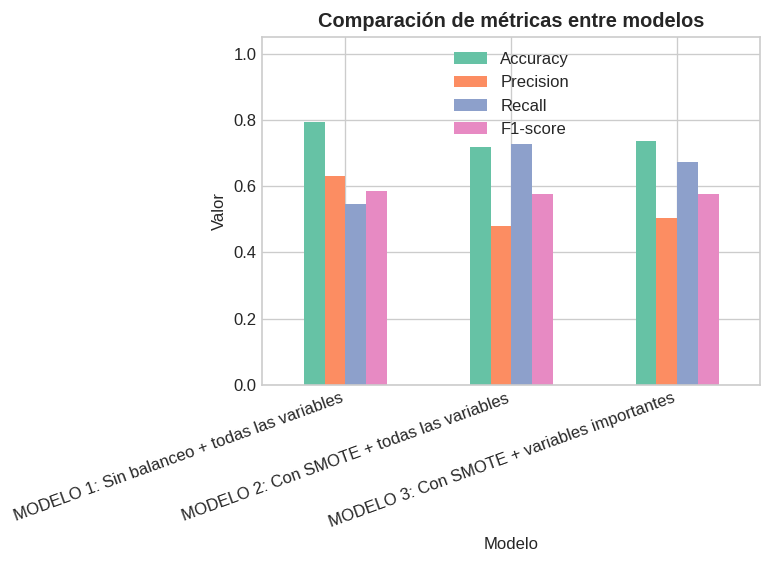

In [ ]:
# ============================================================
# 11. GRÁFICO COMPARATIVO DE MÉTRICAS
# ============================================================
metricas_plot = resultados_df.set_index('Modelo')[['Accuracy', 'Precision', 'Recall', 'F1-score']]

plt.figure(figsize=(10, 6))
metricas_plot.plot(kind='bar')
plt.title('Comparación de métricas entre modelos', fontweight='bold')
plt.ylabel('Valor')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


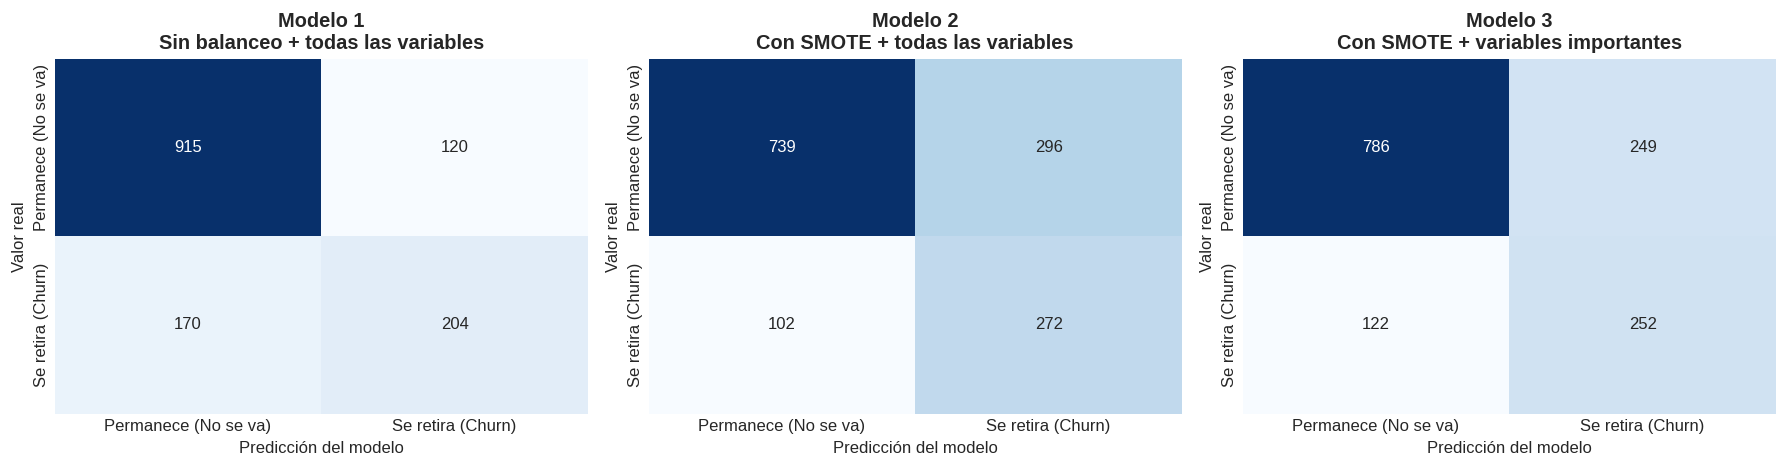

In [ ]:
# ============================================================
# 12. MATRICES DE CONFUSIÓN (EN ESPAÑOL)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cms = [
    confusion_matrix(y_test, y_pred_1),
    confusion_matrix(y_test, y_pred_2),
    confusion_matrix(y_test, y_pred_3)
]

titulos = [
    'Modelo 1\nSin balanceo + todas las variables',
    'Modelo 2\nCon SMOTE + todas las variables',
    'Modelo 3\nCon SMOTE + variables importantes'
]

for ax, cm, titulo in zip(axes, cms, titulos):
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax,
        xticklabels=['Permanece (No se va)', 'Se retira (Churn)'],
        yticklabels=['Permanece (No se va)', 'Se retira (Churn)']
    )
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Predicción del modelo')
    ax.set_ylabel('Valor real')

plt.tight_layout()
plt.show()


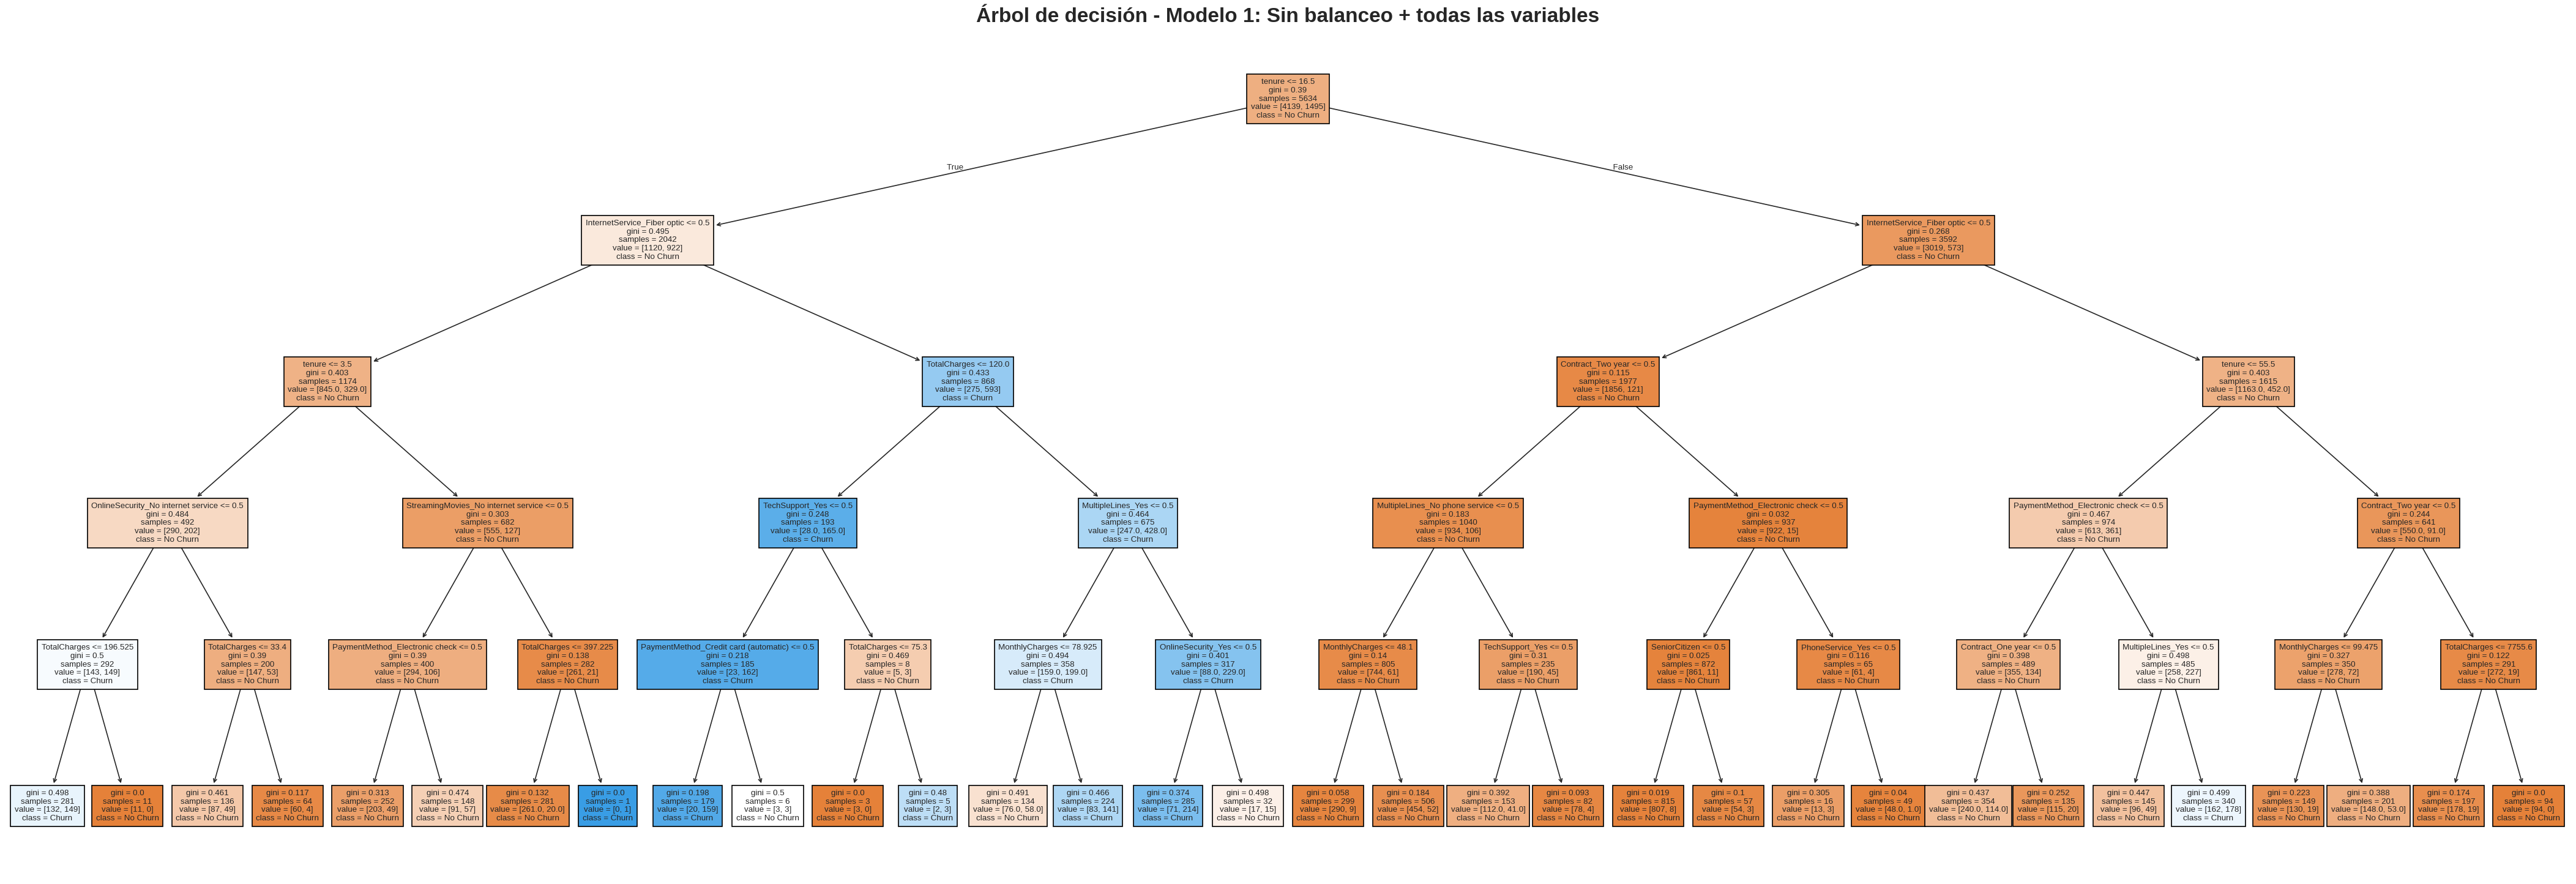

In [ ]:
# ============================================================
# 13. VISUALIZACIÓN DE LOS ÁRBOLES
# ============================================================
plt.figure(figsize=(45,15))
plot_tree(
    modelo1,
    feature_names=X_all_train.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,
    fontsize=8
)
plt.title('Árbol de decisión - Modelo 1: Sin balanceo + todas las variables', fontweight='bold', fontsize=20)
plt.show()



🔴 MODELO 1: SIN BALANCEO + TODAS LAS VARIABLES

Condición: tenure ≤ 16.5

Cuando el árbol indica tenure ≤ 16.5, significa que el cliente tiene poco tiempo en la empresa. En esta parte del árbol, el modelo evalúa a estos clientes como más propensos a retirarse. Esto ocurre porque, al ser nuevos, todavía no han desarrollado fidelidad con la empresa. Sin embargo, como el modelo no está balanceado, muchas veces aun en estos casos sigue clasificando como que el cliente permanece, lo que indica que no logra detectar correctamente todos los casos de churn.

Condición: tenure > 16.5

Cuando el cliente tiene más de 16 meses en la empresa (tenure > 16.5), el modelo lo asocia con mayor probabilidad de permanencia. En esta rama, la mayoría de las decisiones terminan en “No Churn”. Esto refleja que el modelo aprende principalmente del grupo mayoritario, es decir, de los clientes que se quedan, dejando de lado algunos patrones importantes de los clientes que se retiran.

Condición: InternetService_Fiber optic ≤ 0.5

Cuando el cliente no tiene fibra óptica, el modelo evalúa otras variables, pero tiende a mantener la clasificación hacia permanencia. Esto muestra que, en ausencia de balanceo, el modelo no logra identificar correctamente si este grupo tiene riesgo de abandono, sino que prioriza la clase dominante.

Condición: InternetService_Fiber optic > 0.5

Cuando el cliente sí tiene fibra óptica, el modelo realiza divisiones adicionales. En algunos casos logra identificar churn, pero en muchos otros sigue clasificando como permanencia. Esto indica que el modelo no está aprovechando completamente la información de esta variable para detectar abandono.

Conclusión del Modelo 1

En este modelo, aunque el árbol es interpretable y utiliza variables relevantes, se observa que muchas decisiones terminan en “No Churn”. Esto se debe al desbalance de los datos, lo cual provoca que el modelo no aprenda correctamente los patrones de los clientes que se retiran. Como resultado, presenta limitaciones importantes para su uso en un contexto de negocio donde identificar el churn es clave.

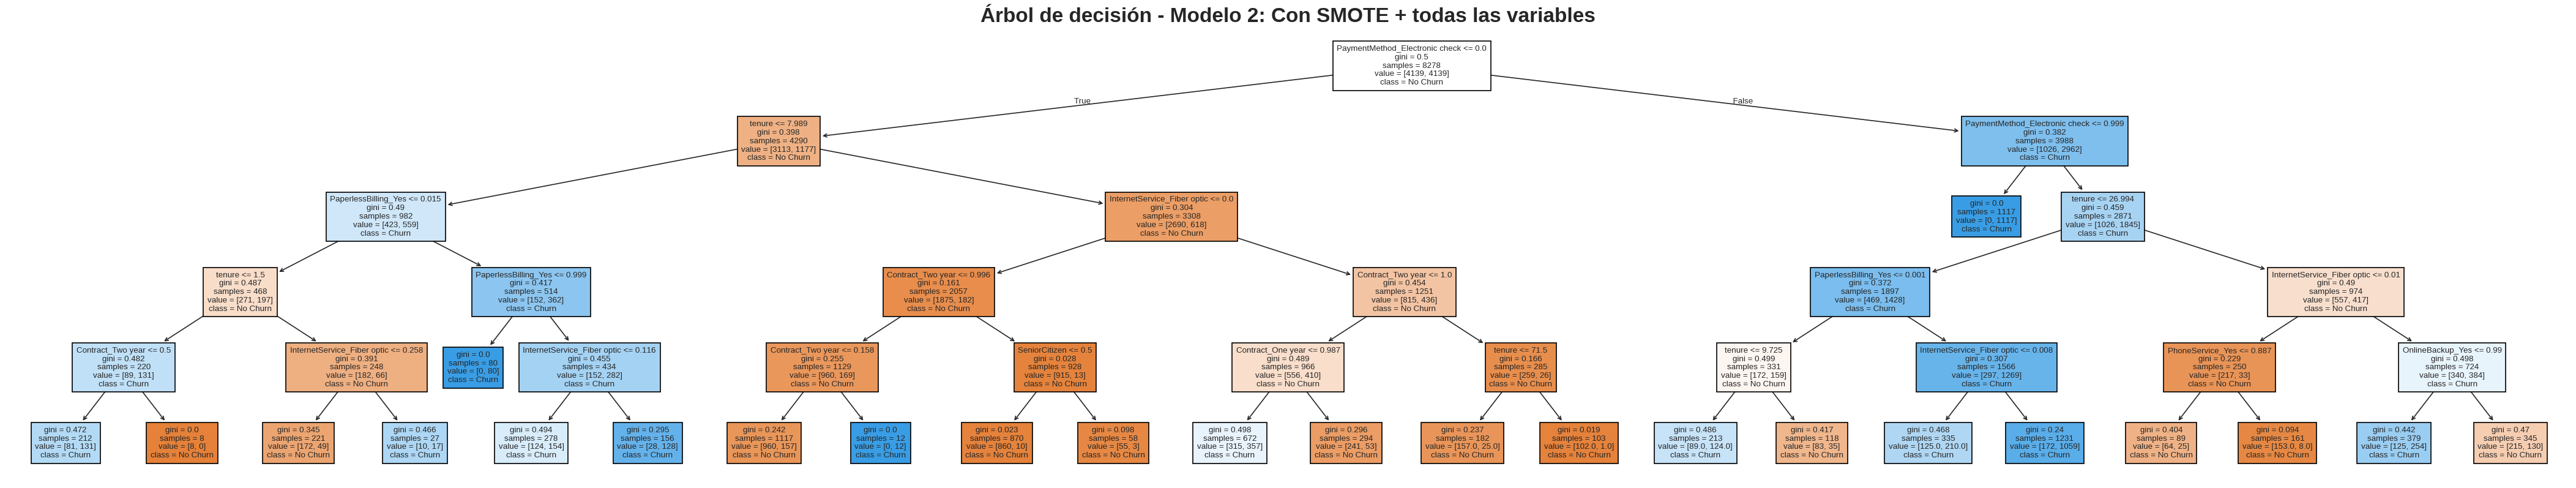

In [ ]:

plt.figure(figsize=(45, 8))
plot_tree(
    modelo2,
    feature_names=X_all_train.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,
    fontsize=8
)
plt.title('Árbol de decisión - Modelo 2: Con SMOTE + todas las variables', fontweight='bold',  fontsize=20)
plt.show()


🟢 MODELO 2: CON SMOTE + TODAS LAS VARIABLES

Condición: PaymentMethod_Electronic check ≤ 0.5

Cuando el árbol indica PaymentMethod_Electronic check ≤ 0.5, significa que el cliente no utiliza pago electrónico. En esta rama, el modelo tiende a clasificar a los clientes como aquellos que permanecen. A diferencia del modelo anterior, esta decisión ya no está tan sesgada, sino que forma parte de una estructura más equilibrada en la que el modelo evalúa mejor ambas clases.

Condición: PaymentMethod_Electronic check > 0.5

Cuando el cliente sí utiliza pago electrónico (> 0.5), el modelo comienza a identificar mayor probabilidad de churn. Esto refleja que, gracias al balanceo con SMOTE, el modelo ahora reconoce patrones asociados a los clientes que se retiran y no se limita solo a la clase mayoritaria.

Condición: tenure ≤ 7.5

Cuando el cliente tiene muy poco tiempo en la empresa (tenure ≤ 7.5), el modelo lo clasifica con mayor frecuencia como churn. Esto confirma que los clientes nuevos presentan mayor riesgo de abandono y que el modelo ahora sí logra capturar este patrón de manera más efectiva.

Condición: tenure > 7.5

Cuando el cliente tiene más tiempo en la empresa, el modelo lo asocia con mayor probabilidad de permanencia. Sin embargo, a diferencia del modelo anterior, aquí todavía se evalúan otras variables antes de tomar la decisión final, lo que hace que el modelo sea más preciso y menos sesgado.

Condición: PaperlessBilling_Yes > 0.5

Cuando el cliente utiliza facturación electrónica, el modelo analiza esta característica junto con otras variables para determinar si el cliente se retirará. En varias ramas, esta condición aparece asociada a churn, lo que indica que este tipo de cliente tiene un comportamiento diferente.

Condición: InternetService_Fiber optic > 0.5

Cuando el cliente tiene fibra óptica, el modelo identifica patrones específicos asociados al abandono. A diferencia del modelo sin balanceo, aquí sí se observa que esta variable ayuda a detectar churn de forma más clara, lo que demuestra que el modelo está aprendiendo mejor de los datos.

Conclusión del Modelo 2

Este modelo presenta un comportamiento mucho más equilibrado. Gracias al uso de SMOTE, el árbol logra identificar mejor a los clientes que se retiran, incorporando variables relevantes desde el inicio y generando decisiones más distribuidas entre churn y no churn. Esto lo convierte en un modelo más adecuado para el negocio, ya que mejora la detección de clientes en riesgo de abandono.

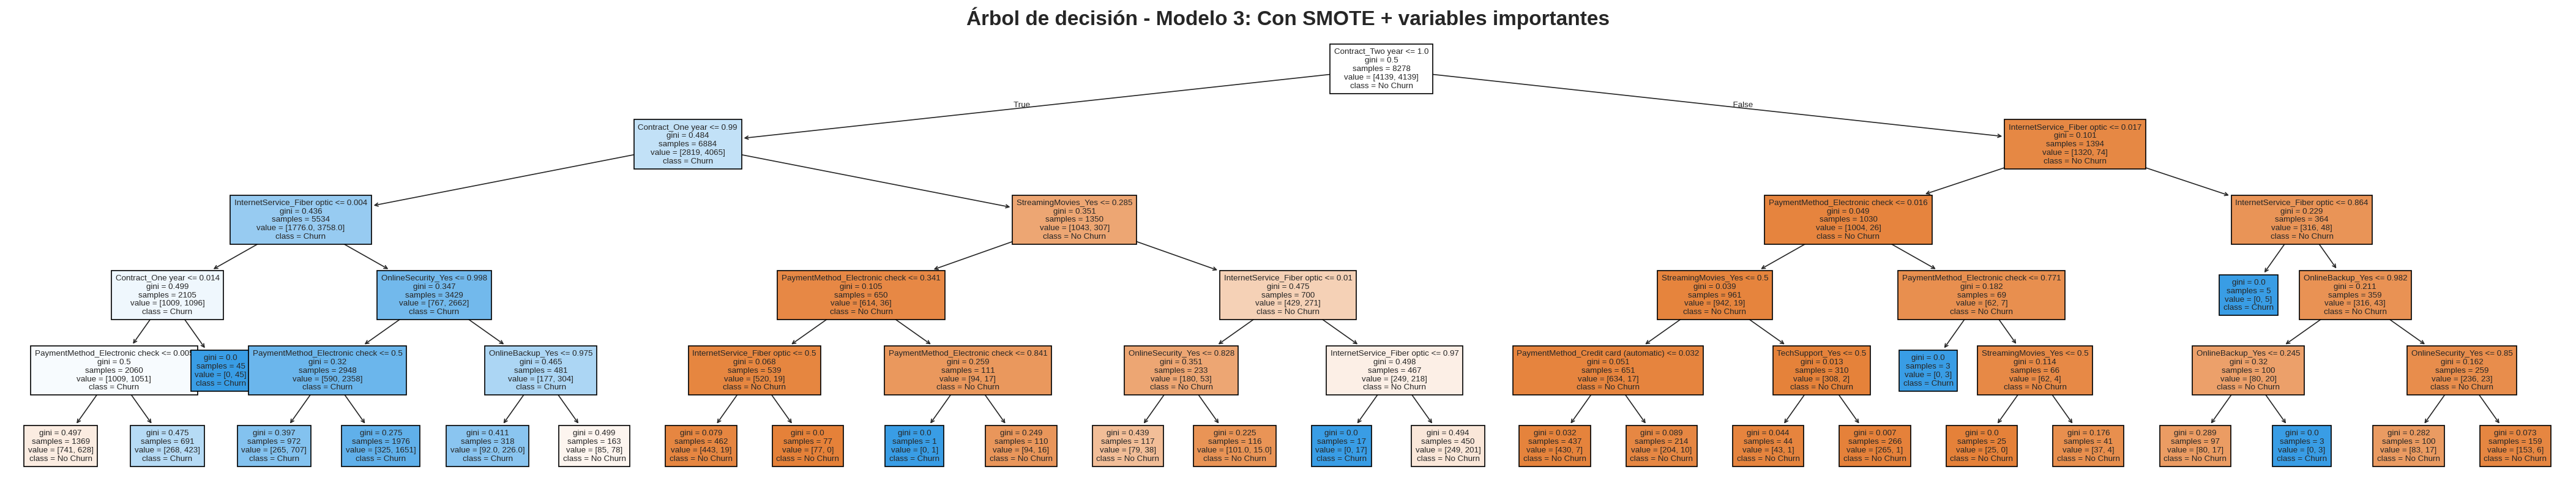

In [ ]:
plt.figure(figsize=(45, 8))
plot_tree(
    modelo3,
    feature_names=X_imp_train.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,
    fontsize=8
)
plt.title('Árbol de decisión - Modelo 3: Con SMOTE + variables importantes', fontweight='bold', fontsize=20)
plt.show()

---

### **1. Condición inicial: PaymentMethod_Electronic check ≤ 0.5**

El árbol inicia evaluando si el cliente utiliza pago electrónico. Cuando se cumple la condición *PaymentMethod_Electronic check ≤ 0.5*, significa que el cliente no usa este tipo de pago. En este caso, el modelo tiende a clasificar a estos clientes como aquellos que permanecen en la empresa. Esto indica que los clientes que no usan pago electrónico presentan menor riesgo de abandono.

---

### **2. Condición: PaymentMethod_Electronic check > 0.5**

Cuando el valor es mayor a 0.5, el cliente sí utiliza pago electrónico. En esta rama, el modelo empieza a identificar una mayor probabilidad de churn. Esto sugiere que los clientes que usan este método de pago tienen un comportamiento más inestable o mayor tendencia a retirarse.

---

### **3. Condición: tenure ≤ 7.5 (o valor cercano)**

Dentro de algunas ramas, aparece la condición *tenure ≤ 7.5*, lo que significa que el cliente tiene muy poco tiempo en la empresa. En estos casos, el modelo tiende a clasificar a estos clientes como churn. Esto refuerza la idea de que los clientes nuevos son los más propensos a abandonar el servicio.

---

### **4. Condición: tenure > 7.5**

Cuando el cliente tiene más tiempo en la empresa (*tenure > 7.5*), el modelo cambia su comportamiento y tiende a clasificarlo como cliente que permanece. Esto muestra que la antigüedad del cliente es un factor clave para la fidelización.

---

### **5. Condición: PaperlessBilling_Yes ≤ 0.5**

Cuando el cliente no utiliza facturación electrónica (*PaperlessBilling ≤ 0.5*), el modelo lo clasifica generalmente como cliente que permanece. Esto puede interpretarse como que los clientes con hábitos más tradicionales tienen menor probabilidad de abandonar la empresa.

---

### **6. Condición: PaperlessBilling_Yes > 0.5**

Cuando el cliente sí utiliza facturación electrónica, el modelo necesita evaluar otras variables para determinar su comportamiento. En algunos casos, estos clientes muestran mayor probabilidad de churn, lo que indica que este factor también influye en el abandono.

---

### **7. Condición: InternetService_Fiber optic > 0.5**

Cuando el cliente tiene fibra óptica (*valor mayor a 0.5*), el modelo lo separa porque este tipo de servicio tiene un comportamiento particular. En varias ramas, estos clientes presentan mayor probabilidad de abandono, lo que sugiere que el tipo de servicio contratado influye directamente en la satisfacción del cliente.

---

### **8. Condición: Contract_Two year o Contract_One year ≤ o >**

El árbol también evalúa el tipo de contrato. Cuando el cliente tiene contratos largos (como de uno o dos años), el modelo tiende a clasificarlo como cliente que permanece. En cambio, cuando no tiene estos contratos, aumenta la probabilidad de churn. Esto refleja que los contratos de mayor duración generan mayor compromiso.

---

### **9. Interpretación general del árbol (con SMOTE)**

En este modelo, a diferencia del anterior, el árbol cambia su lógica inicial y empieza evaluando el método de pago. Esto indica que, al aplicar SMOTE, el modelo logra prestar más atención a variables que ayudan a identificar a los clientes que se van. El árbol se vuelve más equilibrado y no se enfoca únicamente en los clientes que permanecen.

---

### **10. Conclusión del modelo 2**

Este modelo muestra una mejor capacidad para identificar a los clientes que se retiran, ya que incorpora el balanceo de datos mediante SMOTE. Como resultado, el árbol toma decisiones más equilibradas y considera variables relevantes desde el inicio. Esto lo convierte en un modelo más útil para el negocio, ya que permite detectar de forma más efectiva a los clientes en riesgo de abandono.

---




## Introducción para el mejor modelo

En esta parte del laboratorio vamos a pasar del análisis exploratorio al modelado predictivo. Hasta ahora hemos identificado qué variables son más importantes y hemos comprendido el comportamiento del dataset; sin embargo, ahora queremos responder a una pregunta clave: ¿qué modelo permite identificar mejor a los clientes que se van?

Para ello, construiremos y compararemos tres modelos de clasificación: uno sin tratamiento del desbalance y dos aplicando la técnica SMOTE, incluyendo además un modelo que utiliza únicamente las variables más relevantes según la ganancia de información.

El objetivo no es solo obtener un modelo con alta exactitud, sino evaluar cuál es más útil para el negocio, es decir, cuál logra detectar mejor a los clientes en riesgo de abandono. Por esta razón, nos enfocaremos en métricas como el recall y el F1-score.

A continuación, se presentan los códigos que permiten entrenar, evaluar y comparar estos modelos, con el fin de identificar cuál ofrece el mejor desempeño en la predicción del churn.

In [ ]:
# ============================================================
# 14. MEJOR MODELO SEGÚN F1 Y RECALL
# ============================================================
mejor_modelo = resultados_df.sort_values(by=['F1-score', 'Recall'], ascending=False).iloc[0]

print("\n" + "="*70)
print("MEJOR MODELO SEGÚN F1-SCORE Y RECALL")
print("="*70)
print(mejor_modelo[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-score']].round(4))


MEJOR MODELO SEGÚN F1-SCORE Y RECALL
Modelo       MODELO 1: Sin balanceo + todas las variables
Accuracy                                          0.79418
Precision                                         0.62963
Recall                                           0.545455
F1-score                                         0.584527
Name: 0, dtype: object


In [ ]:
mejor_modelo = resultados_df.sort_values(by=['Recall'], ascending=False).iloc[0]
print("\n" + "="*70)
print("MEJOR MODELO SEGÚN F1-SCORE")
print("="*70)
print(mejor_modelo[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-score']].round(4))


MEJOR MODELO SEGÚN F1-SCORE
Modelo       MODELO 2: Con SMOTE + todas las variables
Accuracy                                       0.71753
Precision                                     0.478873
Recall                                        0.727273
F1-score                                      0.577495
Name: 1, dtype: object


Aunque el modelo 1 presenta un mayor F1-score, no es el más adecuado para el problema de churn, ya que no logra identificar correctamente a los clientes que se retiran. En este contexto, el recall de la clase churn es la métrica más importante. Por ello, el modelo 2 resulta más apropiado, ya que reduce significativamente los falsos negativos y mejora la detección de clientes en riesgo de abandono.

**Conclusión**

Aunque el modelo sin balanceo presenta una mayor cantidad de aciertos en la diagonal, no es el más adecuado, ya que no logra identificar correctamente a los clientes que se retiran. El modelo con SMOTE mejora significativamente la detección de la clase churn, reduciendo los falsos negativos de 170 a 102. Por ello, el modelo 2 es el más adecuado, ya que permite identificar con mayor precisión a los clientes en riesgo de abandono, lo cual es clave para la toma de decisiones en la empresa.